# Beta ablations

Root: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code
Beta ablation: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/results_clean/generalization/final_linear_5grid_tabular_beta_ablation.csv FOUND

Best result for every beta update type:


,problem,beta_update,T,eta,rho,beta_projection_radius,greedy_success_rate,solver_success_rate,greedy_avg_reward,solver_avg_reward,elapsed_seconds
0,deterministic,projected_gradient,3000,0.0010,0.050,NaN,1.00,0.83,0.93000,0.72010,304.913882
1,deterministic,fogas_diag,1500,0.0001,0.003,NaN,1.00,0.79,0.93000,0.67000,195.386761
2,deterministic,fogas_full,1500,0.0001,0.003,NaN,1.00,0.79,0.93000,0.67000,1186.753156
3,deterministic,fenchel_mirror,3000,0.0100,0.050,NaN,1.00,0.76,0.93000,0.64800,502.799291
4,deterministic,fenchel_br,3000,0.0001,0.050,NaN,0.00,0.14,-0.20000,-0.05170,475.107751
5,stochastic,fenchel_mirror,3000,0.2000,1.000,NaN,0.91,0.67,-0.02260,-0.75045,85.722479
6,stochastic,fogas_diag,3000,0.0030,0.300,NaN,0.90,0.75,-0.04115,-0.53165,185.129628
7,stochastic,fogas_full,3000,0.0030,0.300,NaN,0.90,0.75,-0.04115,-0.53165,185.664903
8,stochastic,projected_gradient,1500,0.0010,1.000,2.0,0.90,0.60,-0.03460,-0.93770,100.118059
9,stochastic,fenchel_br,3000,0.0001,1.000,NaN,0.09,0.29,-1.90850,-1.57635,95.164489



Best beta-update results: deterministic


,problem,beta_update,T,eta,rho,beta_projection_radius,greedy_success_rate,solver_success_rate,greedy_avg_reward,solver_avg_reward,elapsed_seconds
0,deterministic,projected_gradient,3000,0.0010,0.050,NaN,1.0,0.83,0.93,0.7201,304.913882
1,deterministic,fogas_diag,1500,0.0001,0.003,NaN,1.0,0.79,0.93,0.6700,195.386761
2,deterministic,fogas_full,1500,0.0001,0.003,NaN,1.0,0.79,0.93,0.6700,1186.753156
3,deterministic,fenchel_mirror,3000,0.0100,0.050,NaN,1.0,0.76,0.93,0.6480,502.799291
4,deterministic,fenchel_br,3000,0.0001,0.050,NaN,0.0,0.14,-0.20,-0.0517,475.107751



Best beta-update results: stochastic


,problem,beta_update,T,eta,rho,beta_projection_radius,greedy_success_rate,solver_success_rate,greedy_avg_reward,solver_avg_reward,elapsed_seconds
5,stochastic,fenchel_mirror,3000,0.2000,1.0,NaN,0.91,0.67,-0.02260,-0.75045,85.722479
6,stochastic,fogas_diag,3000,0.0030,0.3,NaN,0.90,0.75,-0.04115,-0.53165,185.129628
7,stochastic,fogas_full,3000,0.0030,0.3,NaN,0.90,0.75,-0.04115,-0.53165,185.664903
8,stochastic,projected_gradient,1500,0.0010,1.0,2.0,0.90,0.60,-0.03460,-0.93770,100.118059
9,stochastic,fenchel_br,3000,0.0001,1.0,NaN,0.09,0.29,-1.90850,-1.57635,95.164489


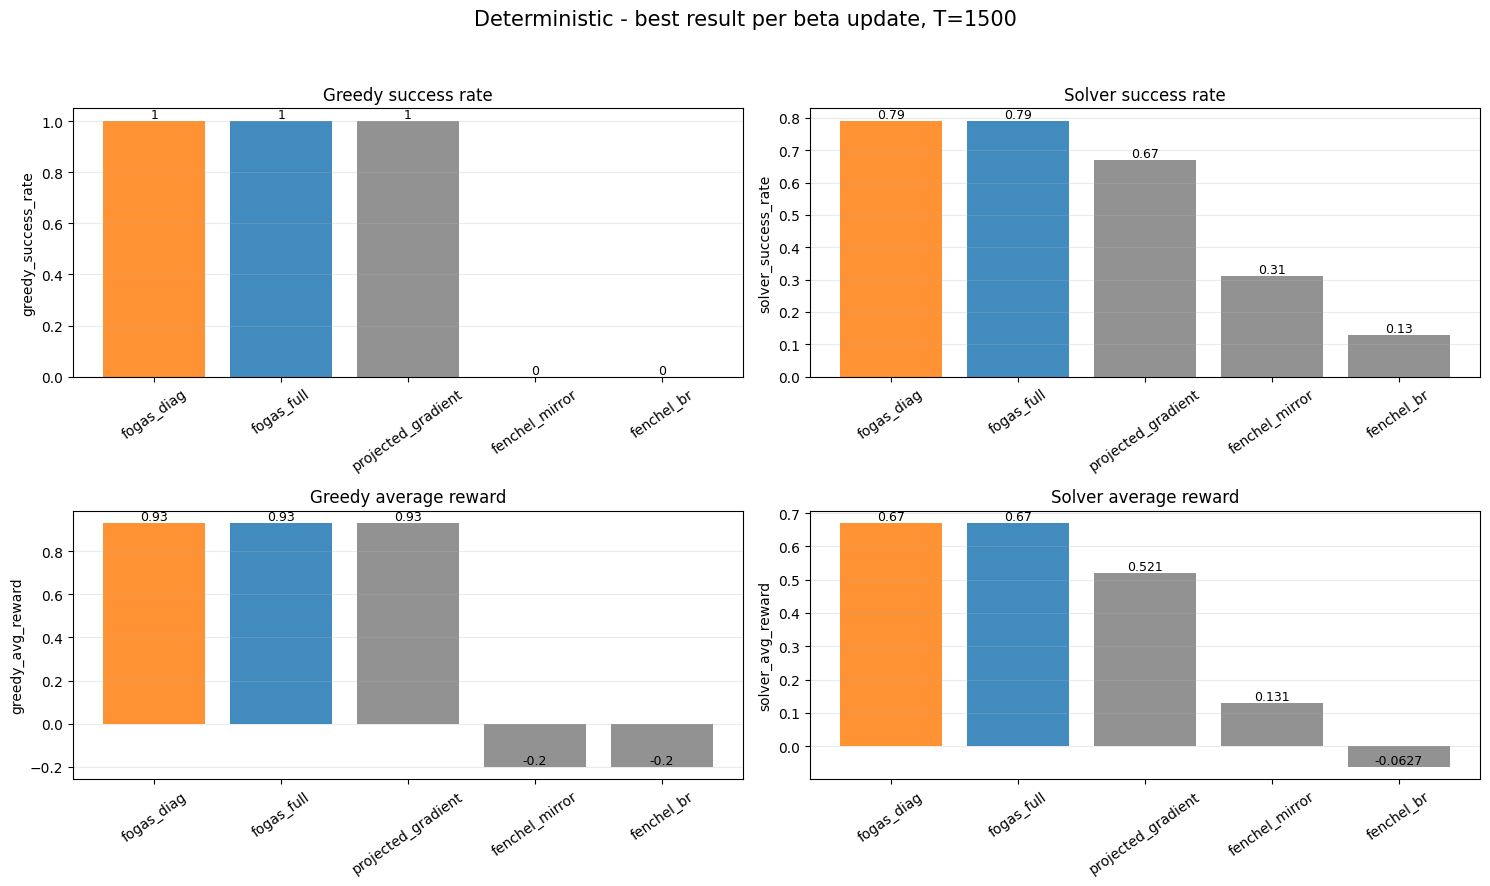

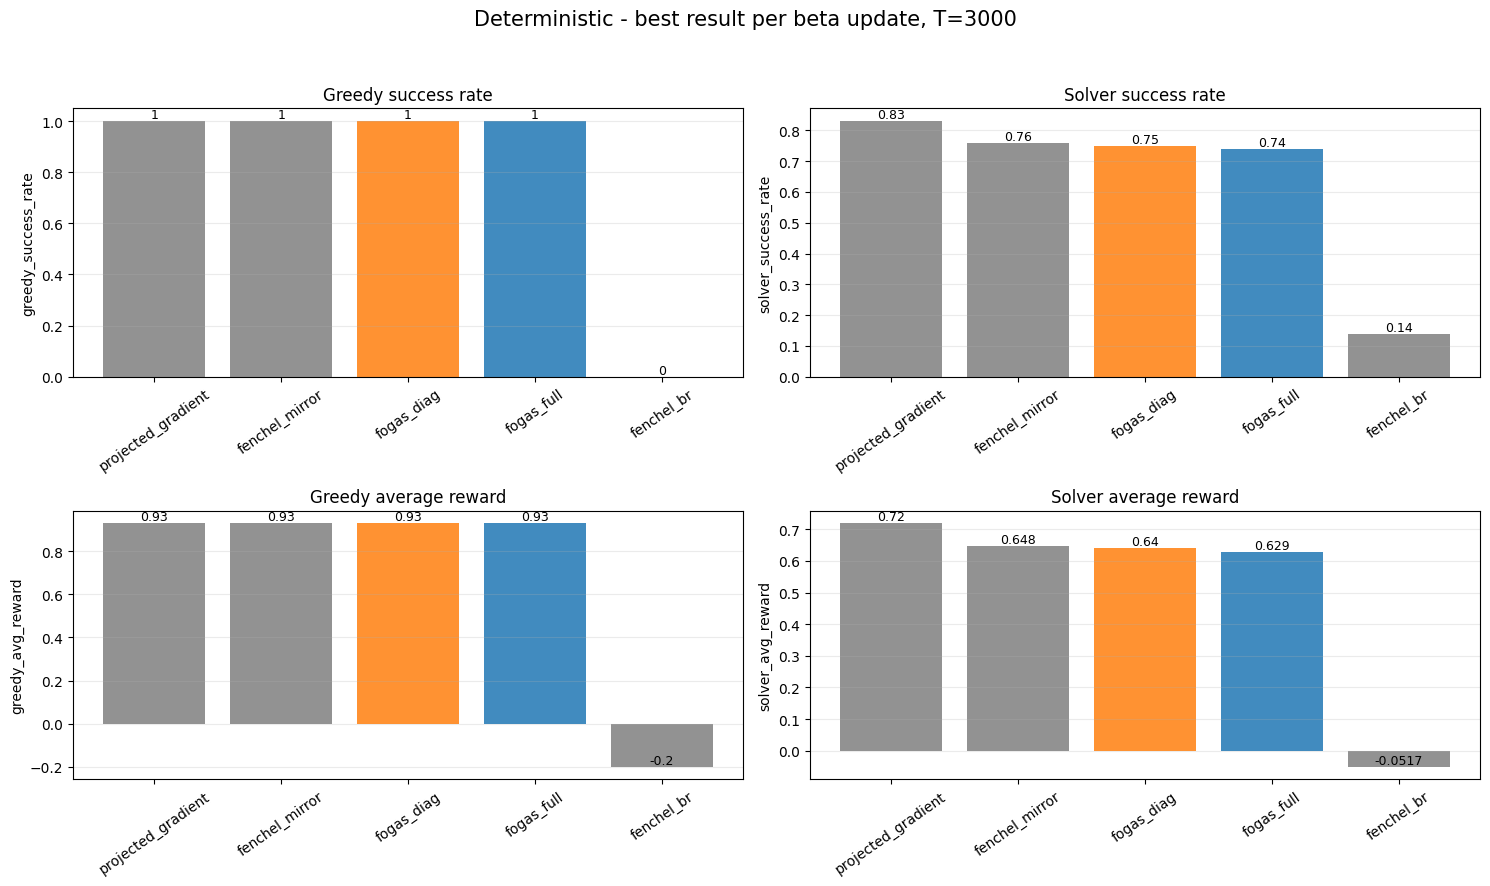

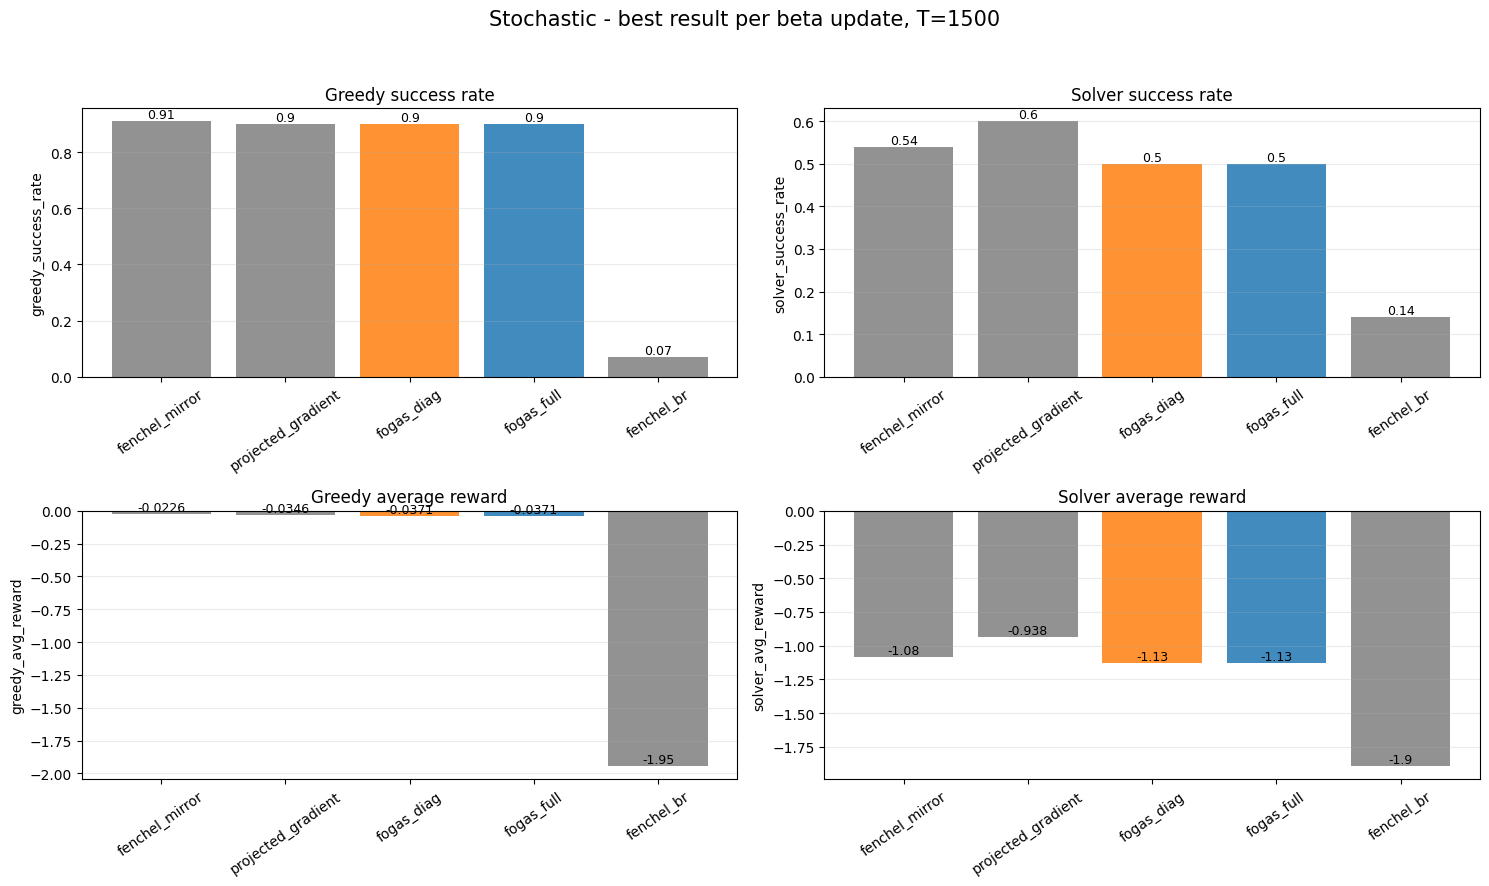

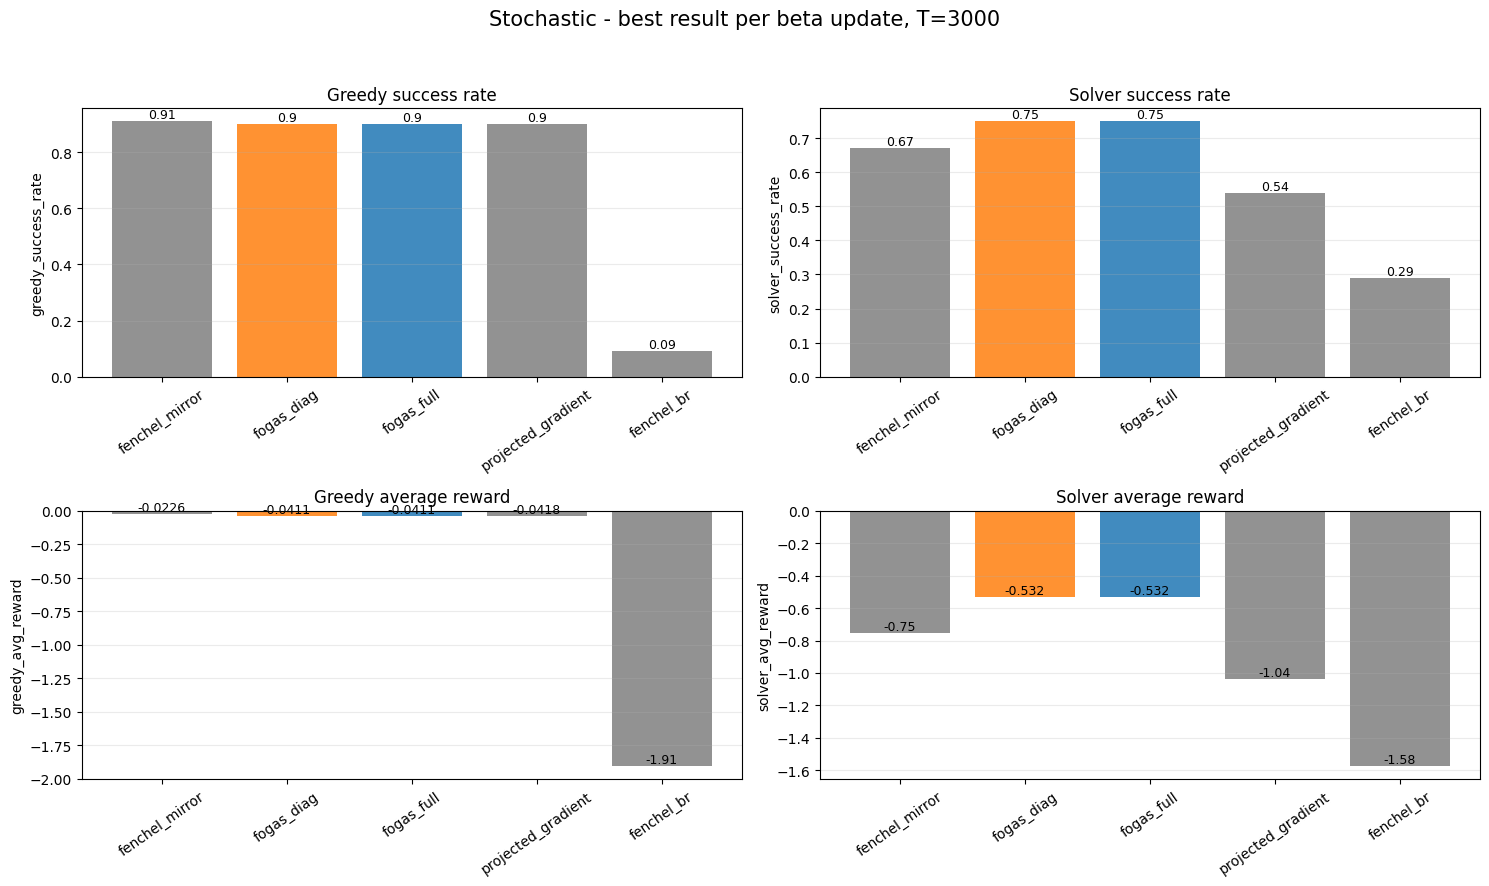


Best rows used for the plots:


,problem,T,beta_update,eta,rho,beta_projection_radius,greedy_success_rate,solver_success_rate,greedy_avg_reward,solver_avg_reward
1,deterministic,1500,fogas_diag,0.0001,0.003,NaN,1.00,0.79,0.93000,0.67000
0,deterministic,1500,fogas_full,0.0001,0.003,NaN,1.00,0.79,0.93000,0.67000
4,deterministic,1500,projected_gradient,0.0010,0.050,2.0,1.00,0.67,0.93000,0.52060
2,deterministic,1500,fenchel_mirror,0.0100,0.050,NaN,0.00,0.31,-0.20000,0.13090
3,deterministic,1500,fenchel_br,0.0001,0.050,NaN,0.00,0.13,-0.20000,-0.06270
9,deterministic,3000,projected_gradient,0.0010,0.050,NaN,1.00,0.83,0.93000,0.72010
7,deterministic,3000,fenchel_mirror,0.0100,0.050,NaN,1.00,0.76,0.93000,0.64800
6,deterministic,3000,fogas_diag,0.0010,0.500,NaN,1.00,0.75,0.93000,0.64050
5,deterministic,3000,fogas_full,0.0005,0.500,NaN,1.00,0.74,0.93000,0.62920
8,deterministic,3000,fenchel_br,0.0001,0.050,NaN,0.00,0.14,-0.20000,-0.05170


In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / "setup.py").exists() and (p / "data").exists():
            return p
    return Path.cwd()


ROOT = find_repo_root()
RESULTS_DIR = ROOT / "data" / "results_clean" / "generalization"
BETA_CSV = RESULTS_DIR / "final_linear_5grid_tabular_beta_ablation.csv"

METRICS = [
    "greedy_success_rate",
    "solver_success_rate",
    "greedy_avg_reward",
    "solver_avg_reward",
]

PROBLEM_ORDER = ["deterministic", "stochastic"]
T_ORDER = [1500, 3000]

UPDATE_ORDER = [
    "fogas_full",
    "fogas_diag",
    "fenchel_mirror",
    "fenchel_br",
    "projected_gradient",
]

RANK_COLUMNS = [
    "greedy_success_rate",
    "solver_success_rate",
    "greedy_avg_reward",
    "solver_avg_reward",
    "elapsed_seconds",
]

RANK_ASCENDING = [
    False,
    False,
    False,
    False,
    True,
]


print("Root:", ROOT)
print("Beta ablation:", BETA_CSV, "FOUND" if BETA_CSV.exists() else "MISSING")

if not BETA_CSV.exists():
    raise FileNotFoundError(
        f"Missing beta ablation CSV: {BETA_CSV}\n"
        "Run:\n"
        "python experiments/fogas_generalization_clean/scripts/"
        "grid_search_final_linear_5grid_tabular_beta_ablation.py --resume"
    )

df = pd.read_csv(BETA_CSV)

if "status" in df.columns:
    df = df[df["status"].eq("ok")].copy()

if df.empty:
    raise ValueError("Beta ablation CSV has no successful rows.")

rename = {
    "solver_avg_return": "solver_avg_reward",
    "greedy_avg_return": "greedy_avg_reward",
}
df = df.rename(columns={k: v for k, v in rename.items() if k in df.columns})

missing = [c for c in ["problem", "beta_update", "T", "eta", "rho", *METRICS] if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["run_order"] = df["run_idx"] if "run_idx" in df.columns else np.arange(len(df))

if "beta_projection_radius" not in df.columns:
    df["beta_projection_radius"] = np.nan

df["problem"] = pd.Categorical(df["problem"], categories=PROBLEM_ORDER, ordered=True)
df["beta_update"] = pd.Categorical(df["beta_update"], categories=UPDATE_ORDER, ordered=True)

rank_cols = [c for c in RANK_COLUMNS if c in df.columns]
rank_ascending = RANK_ASCENDING[: len(rank_cols)]


def best_rows_per_group(data, group_cols):
    return (
        data.sort_values(group_cols + rank_cols, ascending=[True] * len(group_cols) + rank_ascending)
        .groupby(group_cols, as_index=False, observed=True)
        .head(1)
        .reset_index(drop=True)
    )


# ============================================================
# 1. Statistics: best performance per update type
#    Deterministic first, then stochastic.
# ============================================================

best_by_update = best_rows_per_group(df, ["problem", "beta_update"])

best_by_update = best_by_update.sort_values(
    ["problem", *rank_cols],
    ascending=[True] + rank_ascending,
).reset_index(drop=True)

stats_columns = [
    "problem",
    "beta_update",
    "T",
    "eta",
    "rho",
    "beta_projection_radius",
    *METRICS,
]

if "elapsed_seconds" in best_by_update.columns:
    stats_columns.append("elapsed_seconds")

print("\nBest result for every beta update type:")
display(best_by_update[stats_columns])


for problem in PROBLEM_ORDER:
    sub = best_by_update[best_by_update["problem"].astype(str).eq(problem)].copy()
    if sub.empty:
        continue

    print(f"\nBest beta-update results: {problem}")
    display(sub[stats_columns])


# ============================================================
# 2. Plots:
#    For each problem separately,
#    for each T separately,
#    show all 4 metrics for the best row of each update.
# ============================================================

plot_df = df[df["T"].isin(T_ORDER)].copy()
best_by_problem_t_update = best_rows_per_group(
    plot_df,
    ["problem", "T", "beta_update"],
)

metric_titles = {
    "greedy_success_rate": "Greedy success rate",
    "solver_success_rate": "Solver success rate",
    "greedy_avg_reward": "Greedy average reward",
    "solver_avg_reward": "Solver average reward",
}

for problem in PROBLEM_ORDER:
    for T in T_ORDER:
        sub = best_by_problem_t_update[
            best_by_problem_t_update["problem"].astype(str).eq(problem)
            & best_by_problem_t_update["T"].eq(T)
        ].copy()

        if sub.empty:
            print(f"No rows for problem={problem}, T={T}")
            continue

        sub = sub.sort_values(
            rank_cols,
            ascending=rank_ascending,
        )

        updates = sub["beta_update"].astype(str).tolist()

        fig, axes = plt.subplots(2, 2, figsize=(15, 9))
        axes = axes.ravel()

        for ax, metric in zip(axes, METRICS):
            values = sub[metric].astype(float).values

            colors = [
                "tab:blue" if update == "fogas_full"
                else "tab:orange" if update == "fogas_diag"
                else "tab:gray"
                for update in updates
            ]

            ax.bar(updates, values, color=colors, alpha=0.85)
            ax.set_title(metric_titles.get(metric, metric))
            ax.set_ylabel(metric)
            ax.grid(True, axis="y", alpha=0.25)
            ax.tick_params(axis="x", rotation=35)

            for idx, value in enumerate(values):
                ax.text(
                    idx,
                    value,
                    f"{value:.3g}",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                )

        fig.suptitle(
            f"{problem.capitalize()} - best result per beta update, T={T}",
            fontsize=15,
        )
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()


# ============================================================
# 3. Optional compact table used by the plots
# ============================================================

plot_table_columns = [
    "problem",
    "T",
    "beta_update",
    "eta",
    "rho",
    "beta_projection_radius",
    *METRICS,
]

print("\nBest rows used for the plots:")
display(
    best_by_problem_t_update
    .sort_values(["problem", "T", *rank_cols], ascending=[True, True] + rank_ascending)
    [plot_table_columns]
)

# Policy update

Root: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code
Policy ablation: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/results_clean/generalization/final_linear_5grid_tabular_policy_ablation.csv FOUND

Best result for every policy ablation type:


,problem,ablation,policy_optimizer,policy_gradient,alpha,reinforce_samples,fisher_damping,cg_iters,cg_tol,greedy_success_rate,solver_success_rate,greedy_avg_reward,solver_avg_reward,elapsed_seconds
0,deterministic,adam_exact_baseline,adam,exact,0.001,4,0.001,50,1.000000e-10,1.00,0.53,0.93000,0.36860,14.984311
1,deterministic,adam_reinforce_samples,adam,reinforce,0.001,64,0.001,50,1.000000e-10,1.00,0.53,0.93000,0.36860,799.892571
2,deterministic,npg_exact_alpha,npg,exact,0.003,4,0.001,50,1.000000e-10,0.00,0.04,-0.20000,-0.15780,39.915727
3,stochastic,npg_exact_alpha,npg,exact,0.030,4,0.001,50,1.000000e-10,0.22,0.07,-1.58705,-1.93085,60.633141
4,stochastic,adam_exact_baseline,adam,exact,0.001,4,0.001,50,1.000000e-10,0.00,0.01,-2.00090,-1.99700,15.645585
5,stochastic,adam_reinforce_samples,adam,reinforce,0.001,64,0.001,50,1.000000e-10,0.00,0.01,-2.00090,-1.99700,788.140710



Best policy-ablation results: deterministic


,problem,ablation,policy_optimizer,policy_gradient,alpha,reinforce_samples,fisher_damping,cg_iters,cg_tol,greedy_success_rate,solver_success_rate,greedy_avg_reward,solver_avg_reward,elapsed_seconds
0,deterministic,adam_exact_baseline,adam,exact,0.001,4,0.001,50,1.000000e-10,1.0,0.53,0.93,0.3686,14.984311
1,deterministic,adam_reinforce_samples,adam,reinforce,0.001,64,0.001,50,1.000000e-10,1.0,0.53,0.93,0.3686,799.892571
2,deterministic,npg_exact_alpha,npg,exact,0.003,4,0.001,50,1.000000e-10,0.0,0.04,-0.20,-0.1578,39.915727



Best policy-ablation results: stochastic


,problem,ablation,policy_optimizer,policy_gradient,alpha,reinforce_samples,fisher_damping,cg_iters,cg_tol,greedy_success_rate,solver_success_rate,greedy_avg_reward,solver_avg_reward,elapsed_seconds
3,stochastic,npg_exact_alpha,npg,exact,0.030,4,0.001,50,1.000000e-10,0.22,0.07,-1.58705,-1.93085,60.633141
4,stochastic,adam_exact_baseline,adam,exact,0.001,4,0.001,50,1.000000e-10,0.00,0.01,-2.00090,-1.99700,15.645585
5,stochastic,adam_reinforce_samples,adam,reinforce,0.001,64,0.001,50,1.000000e-10,0.00,0.01,-2.00090,-1.99700,788.140710


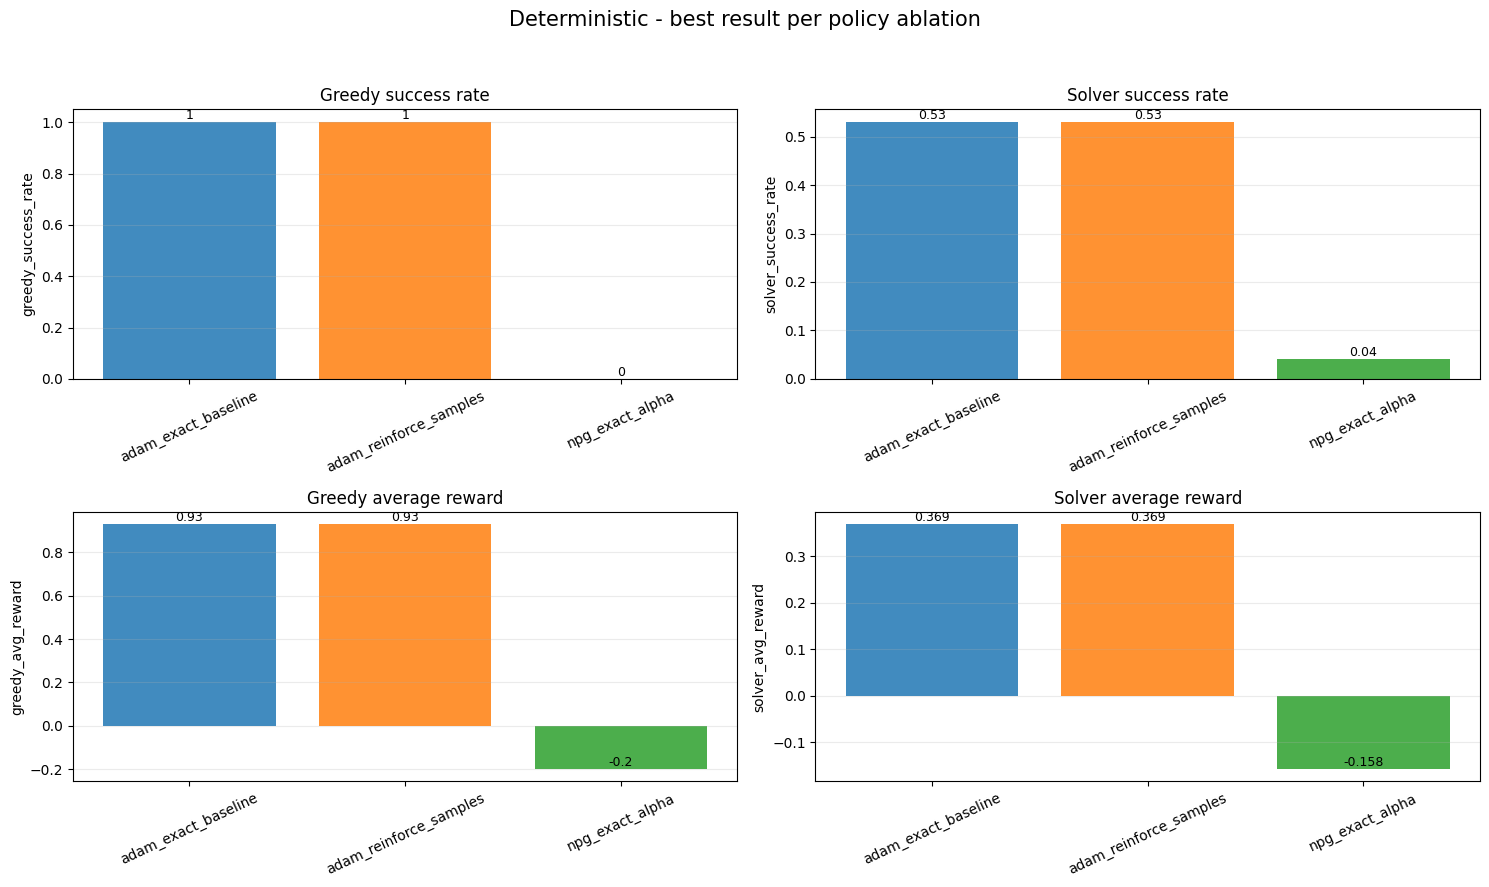

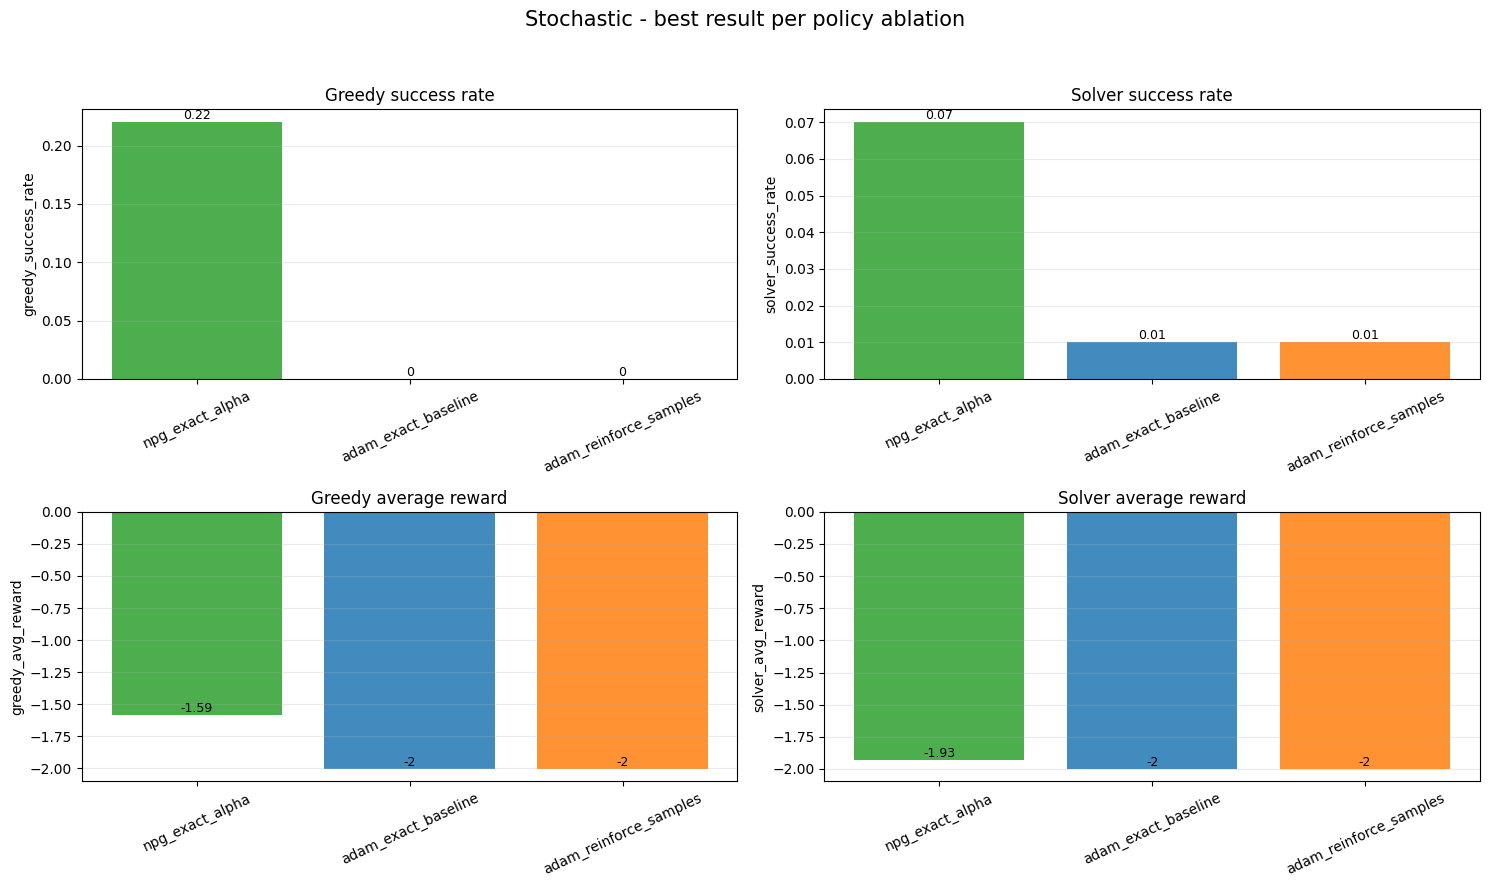

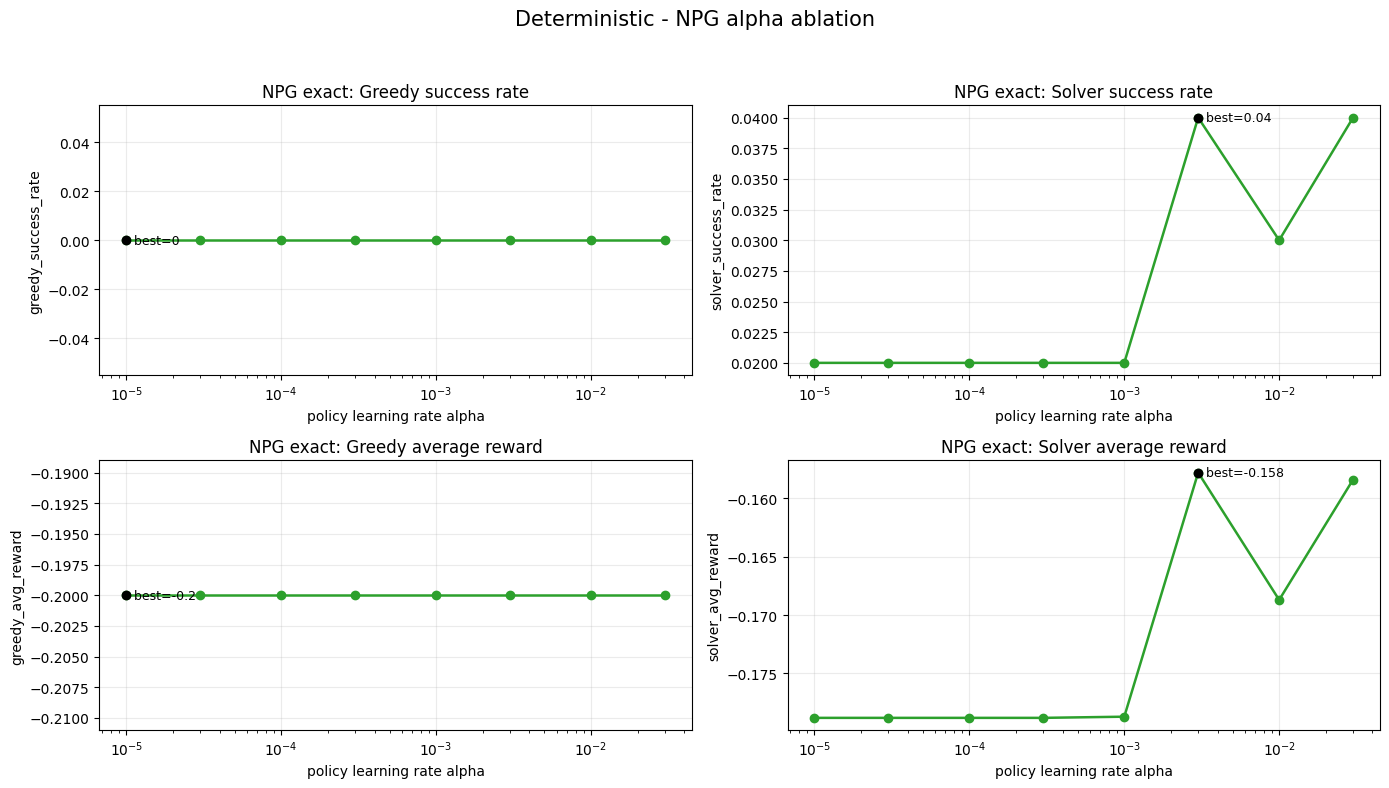

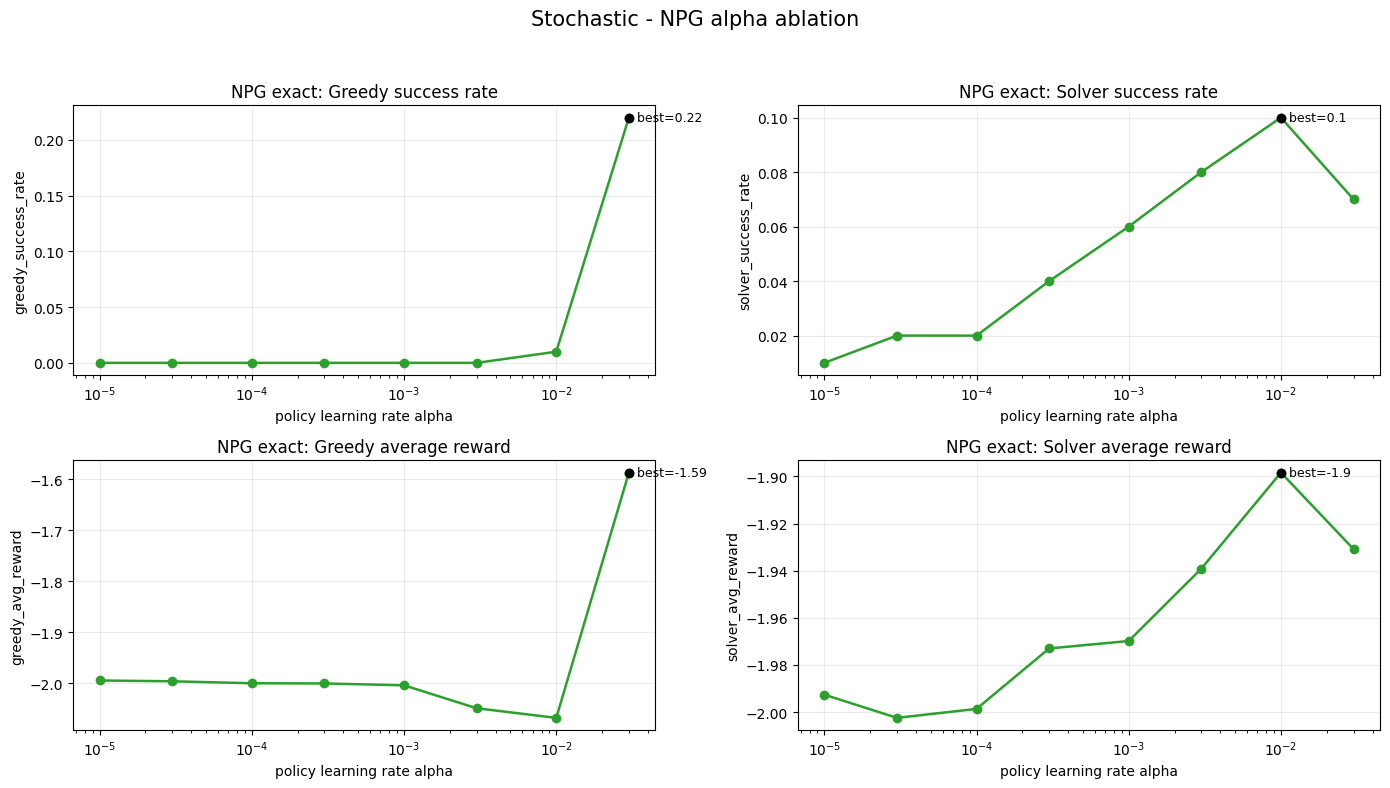

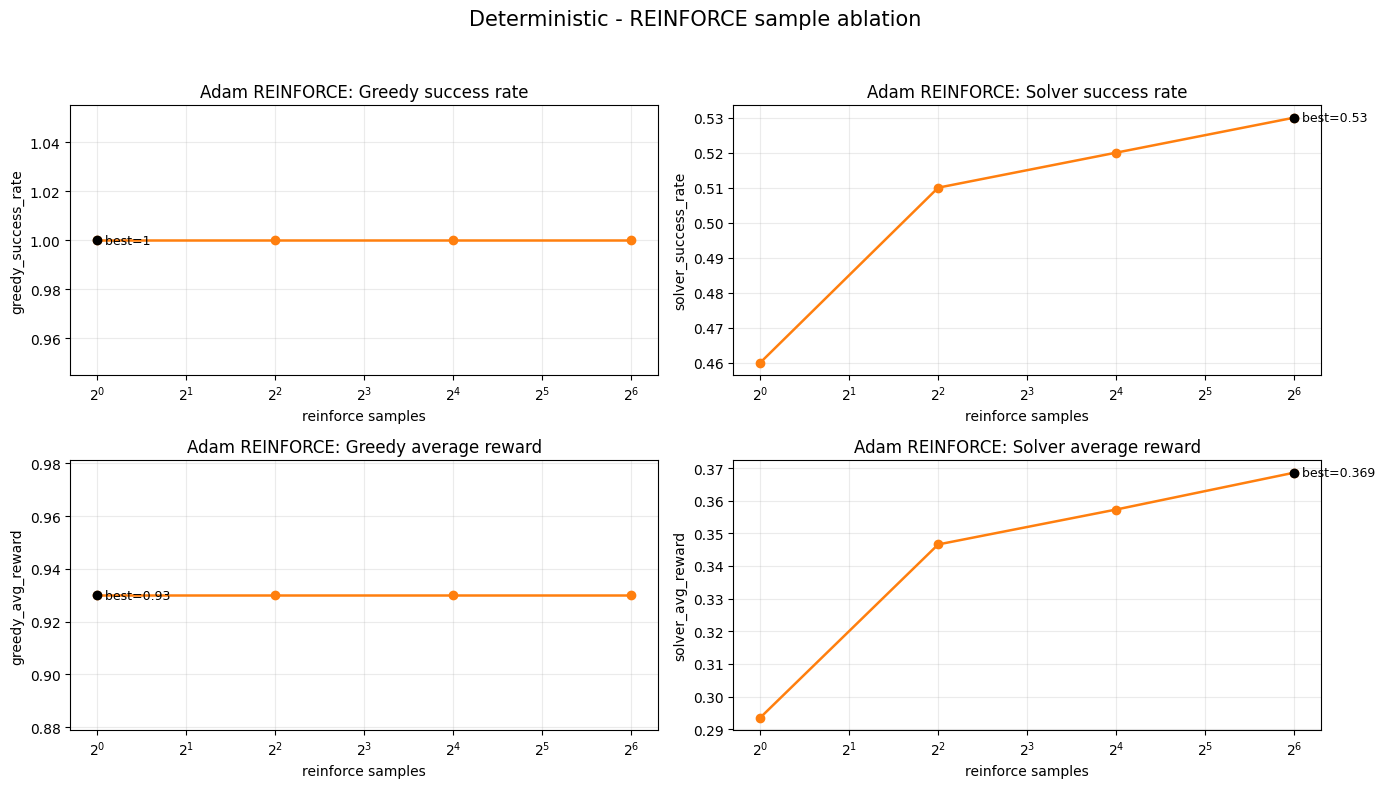

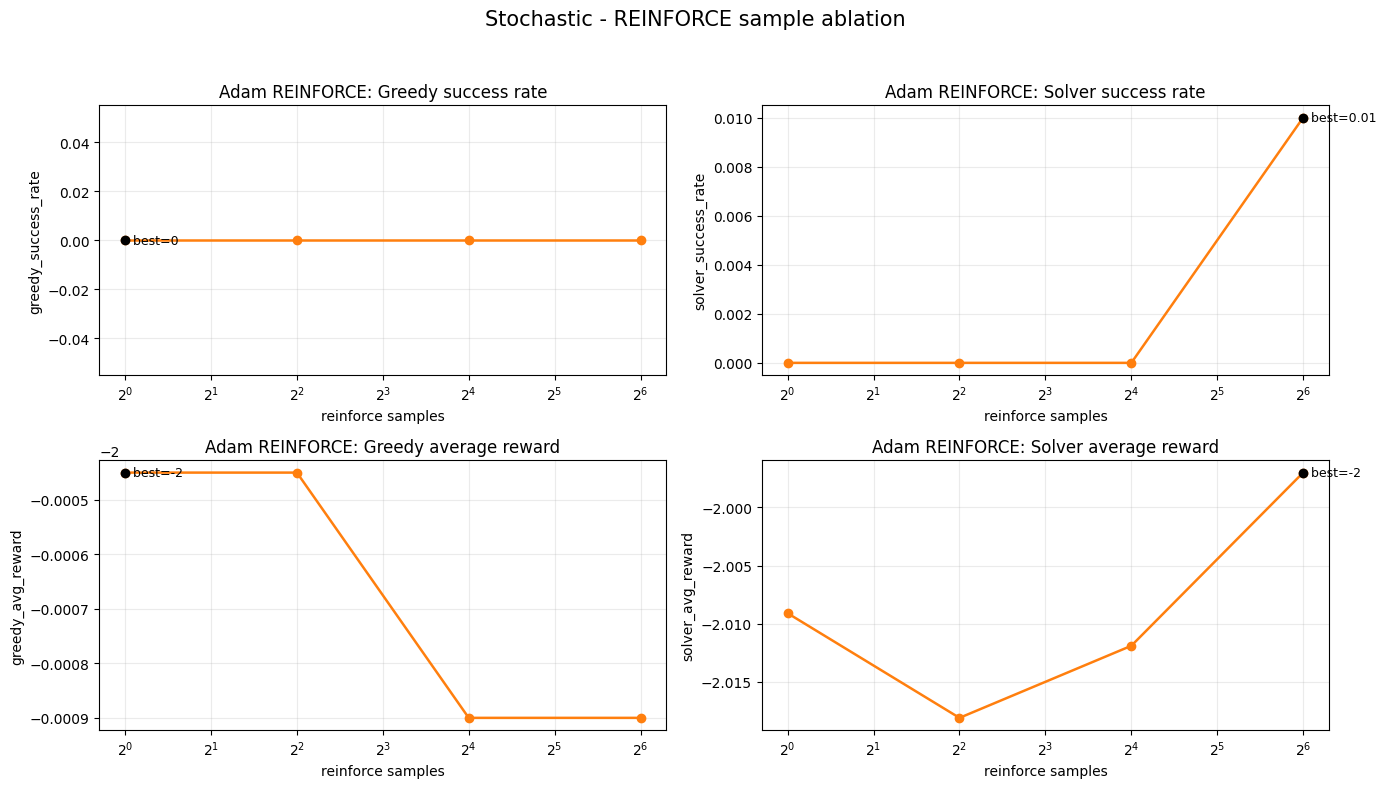


Best rows used for the main policy-ablation plots:


,problem,ablation,policy_optimizer,policy_gradient,alpha,reinforce_samples,greedy_success_rate,solver_success_rate,greedy_avg_reward,solver_avg_reward
0,deterministic,adam_exact_baseline,adam,exact,0.001,4,1.00,0.53,0.93000,0.36860
1,deterministic,adam_reinforce_samples,adam,reinforce,0.001,64,1.00,0.53,0.93000,0.36860
2,deterministic,npg_exact_alpha,npg,exact,0.003,4,0.00,0.04,-0.20000,-0.15780
3,stochastic,npg_exact_alpha,npg,exact,0.030,4,0.22,0.07,-1.58705,-1.93085
4,stochastic,adam_exact_baseline,adam,exact,0.001,4,0.00,0.01,-2.00090,-1.99700
5,stochastic,adam_reinforce_samples,adam,reinforce,0.001,64,0.00,0.01,-2.00090,-1.99700


In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / "setup.py").exists() and (p / "data").exists():
            return p
    return Path.cwd()


ROOT = find_repo_root()
RESULTS_DIR = ROOT / "data" / "results_clean" / "generalization"

POLICY_CSV = RESULTS_DIR / "final_linear_5grid_tabular_policy_ablation.csv"

METRICS = [
    "greedy_success_rate",
    "solver_success_rate",
    "greedy_avg_reward",
    "solver_avg_reward",
]

PROBLEM_ORDER = ["deterministic", "stochastic"]

ABLATION_ORDER = [
    "adam_exact_baseline",
    "adam_reinforce_samples",
    "npg_exact_alpha",
]

RANK_COLUMNS = [
    "greedy_success_rate",
    "solver_success_rate",
    "greedy_avg_reward",
    "solver_avg_reward",
    "elapsed_seconds",
]

RANK_ASCENDING = [
    False,
    False,
    False,
    False,
    True,
]

METRIC_TITLES = {
    "greedy_success_rate": "Greedy success rate",
    "solver_success_rate": "Solver success rate",
    "greedy_avg_reward": "Greedy average reward",
    "solver_avg_reward": "Solver average reward",
}


print("Root:", ROOT)
print("Policy ablation:", POLICY_CSV, "FOUND" if POLICY_CSV.exists() else "MISSING")

if not POLICY_CSV.exists():
    raise FileNotFoundError(
        f"Missing policy ablation CSV: {POLICY_CSV}\n"
        "Run:\n"
        "python experiments/fogas_generalization_clean/scripts/"
        "grid_search_final_linear_5grid_tabular_policy_ablation.py --resume"
    )

df = pd.read_csv(POLICY_CSV)

if "status" in df.columns:
    df = df[df["status"].eq("ok")].copy()

if df.empty:
    raise ValueError("Policy ablation CSV has no successful rows.")

rename = {
    "solver_avg_return": "solver_avg_reward",
    "greedy_avg_return": "greedy_avg_reward",
}
df = df.rename(columns={k: v for k, v in rename.items() if k in df.columns})

required = [
    "problem",
    "ablation",
    "policy_optimizer",
    "policy_gradient",
    "alpha",
    "reinforce_samples",
    *METRICS,
]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["run_order"] = df["run_idx"] if "run_idx" in df.columns else np.arange(len(df))

df["problem"] = pd.Categorical(df["problem"], categories=PROBLEM_ORDER, ordered=True)
df["ablation"] = pd.Categorical(df["ablation"], categories=ABLATION_ORDER, ordered=True)

df["policy_update"] = (
    df["ablation"].astype(str)
    + " | "
    + df["policy_optimizer"].astype(str)
    + "+"
    + df["policy_gradient"].astype(str)
)

rank_cols = [c for c in RANK_COLUMNS if c in df.columns]
rank_ascending = RANK_ASCENDING[: len(rank_cols)]


def best_rows_per_group(data, group_cols):
    return (
        data.sort_values(
            group_cols + rank_cols,
            ascending=[True] * len(group_cols) + rank_ascending,
        )
        .groupby(group_cols, as_index=False, observed=True)
        .head(1)
        .reset_index(drop=True)
    )


# ============================================================
# 1. Statistics:
#    Best performance per policy ablation type.
#    Deterministic first, then stochastic.
# ============================================================

best_by_ablation = best_rows_per_group(df, ["problem", "ablation"])

best_by_ablation = best_by_ablation.sort_values(
    ["problem", *rank_cols],
    ascending=[True] + rank_ascending,
).reset_index(drop=True)

stats_columns = [
    "problem",
    "ablation",
    "policy_optimizer",
    "policy_gradient",
    "alpha",
    "reinforce_samples",
    "fisher_damping",
    "cg_iters",
    "cg_tol",
    *METRICS,
]

if "elapsed_seconds" in best_by_ablation.columns:
    stats_columns.append("elapsed_seconds")

print("\nBest result for every policy ablation type:")
display(best_by_ablation[stats_columns])


for problem in PROBLEM_ORDER:
    sub = best_by_ablation[best_by_ablation["problem"].astype(str).eq(problem)].copy()
    if sub.empty:
        continue

    print(f"\nBest policy-ablation results: {problem}")
    display(sub[stats_columns])


# ============================================================
# 2. Bar plots:
#    For each problem, show all 4 metrics.
#    Each bar is the best result for that policy ablation type.
# ============================================================

for problem in PROBLEM_ORDER:
    sub = best_by_ablation[best_by_ablation["problem"].astype(str).eq(problem)].copy()

    if sub.empty:
        print(f"No rows for problem={problem}")
        continue

    sub = sub.sort_values(rank_cols, ascending=rank_ascending)
    labels = sub["ablation"].astype(str).tolist()

    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    axes = axes.ravel()

    for ax, metric in zip(axes, METRICS):
        values = sub[metric].astype(float).values

        colors = [
            "tab:blue" if label == "adam_exact_baseline"
            else "tab:orange" if label == "adam_reinforce_samples"
            else "tab:green"
            for label in labels
        ]

        ax.bar(labels, values, color=colors, alpha=0.85)
        ax.set_title(METRIC_TITLES.get(metric, metric))
        ax.set_ylabel(metric)
        ax.grid(True, axis="y", alpha=0.25)
        ax.tick_params(axis="x", rotation=25)

        for idx, value in enumerate(values):
            ax.text(
                idx,
                value,
                f"{value:.3g}",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    fig.suptitle(
        f"{problem.capitalize()} - best result per policy ablation",
        fontsize=15,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# ============================================================
# 3. NPG alpha curves:
#    For each problem, plot the 4 metrics as a function of alpha.
# ============================================================

for problem in PROBLEM_ORDER:
    sub = df[
        df["problem"].astype(str).eq(problem)
        & df["ablation"].astype(str).eq("npg_exact_alpha")
    ].copy()

    if sub.empty:
        print(f"No NPG rows for problem={problem}")
        continue

    sub = sub.sort_values("alpha")

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.ravel()

    for ax, metric in zip(axes, METRICS):
        ax.plot(
            sub["alpha"],
            sub[metric],
            marker="o",
            linewidth=1.8,
            color="tab:green",
        )
        ax.set_xscale("log")
        ax.set_title(f"NPG exact: {METRIC_TITLES.get(metric, metric)}")
        ax.set_xlabel("policy learning rate alpha")
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.25)

        best_idx = sub[metric].astype(float).idxmax()
        best_row = sub.loc[best_idx]
        ax.scatter(
            best_row["alpha"],
            best_row[metric],
            color="black",
            zorder=5,
        )
        ax.text(
            best_row["alpha"],
            best_row[metric],
            f"  best={best_row[metric]:.3g}",
            va="center",
            fontsize=9,
        )

    fig.suptitle(f"{problem.capitalize()} - NPG alpha ablation", fontsize=15)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# ============================================================
# 4. REINFORCE sample curves:
#    For each problem, plot the 4 metrics as a function of sample count.
# ============================================================

for problem in PROBLEM_ORDER:
    sub = df[
        df["problem"].astype(str).eq(problem)
        & df["ablation"].astype(str).eq("adam_reinforce_samples")
    ].copy()

    if sub.empty:
        print(f"No REINFORCE rows for problem={problem}")
        continue

    sub = sub.sort_values("reinforce_samples")

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.ravel()

    for ax, metric in zip(axes, METRICS):
        ax.plot(
            sub["reinforce_samples"],
            sub[metric],
            marker="o",
            linewidth=1.8,
            color="tab:orange",
        )
        ax.set_xscale("log", base=2)
        ax.set_title(f"Adam REINFORCE: {METRIC_TITLES.get(metric, metric)}")
        ax.set_xlabel("reinforce samples")
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.25)

        best_idx = sub[metric].astype(float).idxmax()
        best_row = sub.loc[best_idx]
        ax.scatter(
            best_row["reinforce_samples"],
            best_row[metric],
            color="black",
            zorder=5,
        )
        ax.text(
            best_row["reinforce_samples"],
            best_row[metric],
            f"  best={best_row[metric]:.3g}",
            va="center",
            fontsize=9,
        )

    fig.suptitle(f"{problem.capitalize()} - REINFORCE sample ablation", fontsize=15)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# ============================================================
# 5. Compact table used for the plots
# ============================================================

plot_table_columns = [
    "problem",
    "ablation",
    "policy_optimizer",
    "policy_gradient",
    "alpha",
    "reinforce_samples",
    *METRICS,
]

print("\nBest rows used for the main policy-ablation plots:")
display(
    best_by_ablation
    .sort_values(["problem", *rank_cols], ascending=[True] + rank_ascending)
    [plot_table_columns]
)

# Theta update

Root: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code
Theta ablation: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/results_clean/generalization/final_linear_5grid_tabular_theta_ablation.csv FOUND

Best result for every theta ablation type:


,problem,ablation,theta_mode,theta_start_mode,theta_lambda,D_theta,theta_inner_steps,theta_lr,greedy_success_rate,solver_success_rate,greedy_avg_reward,solver_avg_reward,elapsed_seconds
0,deterministic,zero_start_lambda,reg_fixed,zero,1.000000e-04,NaN,40,0.30,1.00,0.97,0.93000,0.86390,56.617689
1,deterministic,reg_fixed_lambda,reg_fixed,warm,1.000000e-04,NaN,40,0.30,1.00,0.96,0.93000,0.84960,61.983536
2,deterministic,zero_start_inner_steps,reg_fixed,zero,1.000000e-03,NaN,2,0.30,1.00,0.65,0.93000,0.50410,49.938261
3,deterministic,reg_fixed_inner_steps,reg_fixed,warm,1.000000e-03,NaN,20,0.30,1.00,0.55,0.93000,0.39000,56.423370
4,deterministic,reg_fixed_baseline,reg_fixed,warm,1.000000e-03,NaN,40,0.30,1.00,0.53,0.93000,0.36860,54.561061
5,deterministic,projection_dtheta,projection,warm,NaN,10.0,40,0.30,1.00,0.46,0.93000,0.28420,61.389564
6,deterministic,reg_fixed_start_zero,reg_fixed,zero,1.000000e-03,NaN,40,0.30,0.00,0.36,-0.20000,0.18260,62.646363
7,stochastic,projection_dtheta,projection,warm,NaN,30.0,40,0.03,0.94,0.64,0.04930,-0.94375,61.738912
8,stochastic,reg_fixed_lambda,reg_fixed,warm,1.000000e-07,NaN,40,0.03,0.94,0.53,0.04930,-1.05575,60.345440
9,stochastic,zero_start_lambda,reg_fixed,zero,1.000000e-03,NaN,40,0.03,0.08,0.06,-1.72530,-2.10210,58.347186



Best theta-ablation results: deterministic


,problem,ablation,theta_mode,theta_start_mode,theta_lambda,D_theta,theta_inner_steps,theta_lr,greedy_success_rate,solver_success_rate,greedy_avg_reward,solver_avg_reward,elapsed_seconds
0,deterministic,zero_start_lambda,reg_fixed,zero,0.0001,NaN,40,0.3,1.0,0.97,0.93,0.8639,56.617689
1,deterministic,reg_fixed_lambda,reg_fixed,warm,0.0001,NaN,40,0.3,1.0,0.96,0.93,0.8496,61.983536
2,deterministic,zero_start_inner_steps,reg_fixed,zero,0.0010,NaN,2,0.3,1.0,0.65,0.93,0.5041,49.938261
3,deterministic,reg_fixed_inner_steps,reg_fixed,warm,0.0010,NaN,20,0.3,1.0,0.55,0.93,0.3900,56.423370
4,deterministic,reg_fixed_baseline,reg_fixed,warm,0.0010,NaN,40,0.3,1.0,0.53,0.93,0.3686,54.561061
5,deterministic,projection_dtheta,projection,warm,NaN,10.0,40,0.3,1.0,0.46,0.93,0.2842,61.389564
6,deterministic,reg_fixed_start_zero,reg_fixed,zero,0.0010,NaN,40,0.3,0.0,0.36,-0.20,0.1826,62.646363



Best theta-ablation results: stochastic


,problem,ablation,theta_mode,theta_start_mode,theta_lambda,D_theta,theta_inner_steps,theta_lr,greedy_success_rate,solver_success_rate,greedy_avg_reward,solver_avg_reward,elapsed_seconds
7,stochastic,projection_dtheta,projection,warm,NaN,30.0,40,0.03,0.94,0.64,0.04930,-0.94375,61.738912
8,stochastic,reg_fixed_lambda,reg_fixed,warm,1.000000e-07,NaN,40,0.03,0.94,0.53,0.04930,-1.05575,60.345440
9,stochastic,zero_start_lambda,reg_fixed,zero,1.000000e-03,NaN,40,0.03,0.08,0.06,-1.72530,-2.10210,58.347186
10,stochastic,zero_start_inner_steps,reg_fixed,zero,1.000000e-04,NaN,1,0.03,0.05,0.05,-2.13070,-2.07785,22.656819
11,stochastic,reg_fixed_inner_steps,reg_fixed,warm,1.000000e-04,NaN,10,0.03,0.00,0.01,-2.00045,-1.99165,52.652076
12,stochastic,reg_fixed_baseline,reg_fixed,warm,1.000000e-04,NaN,40,0.03,0.00,0.01,-2.00090,-1.99700,62.070250
13,stochastic,reg_fixed_start_zero,reg_fixed,zero,1.000000e-04,NaN,40,0.03,0.00,0.00,-2.00970,-2.02290,59.625961


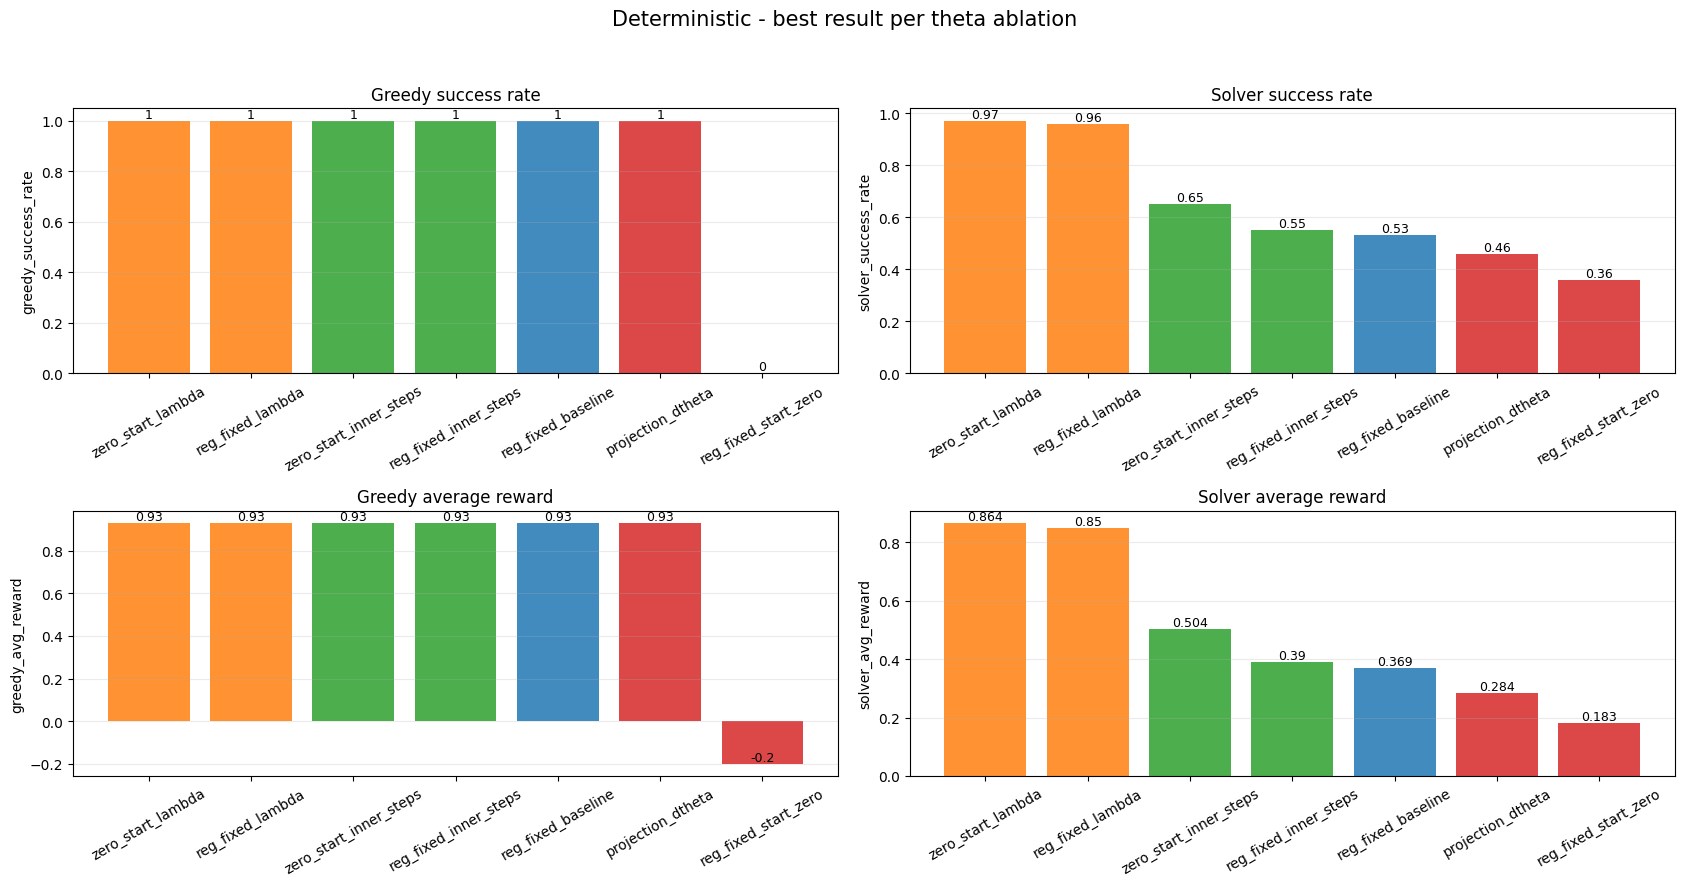

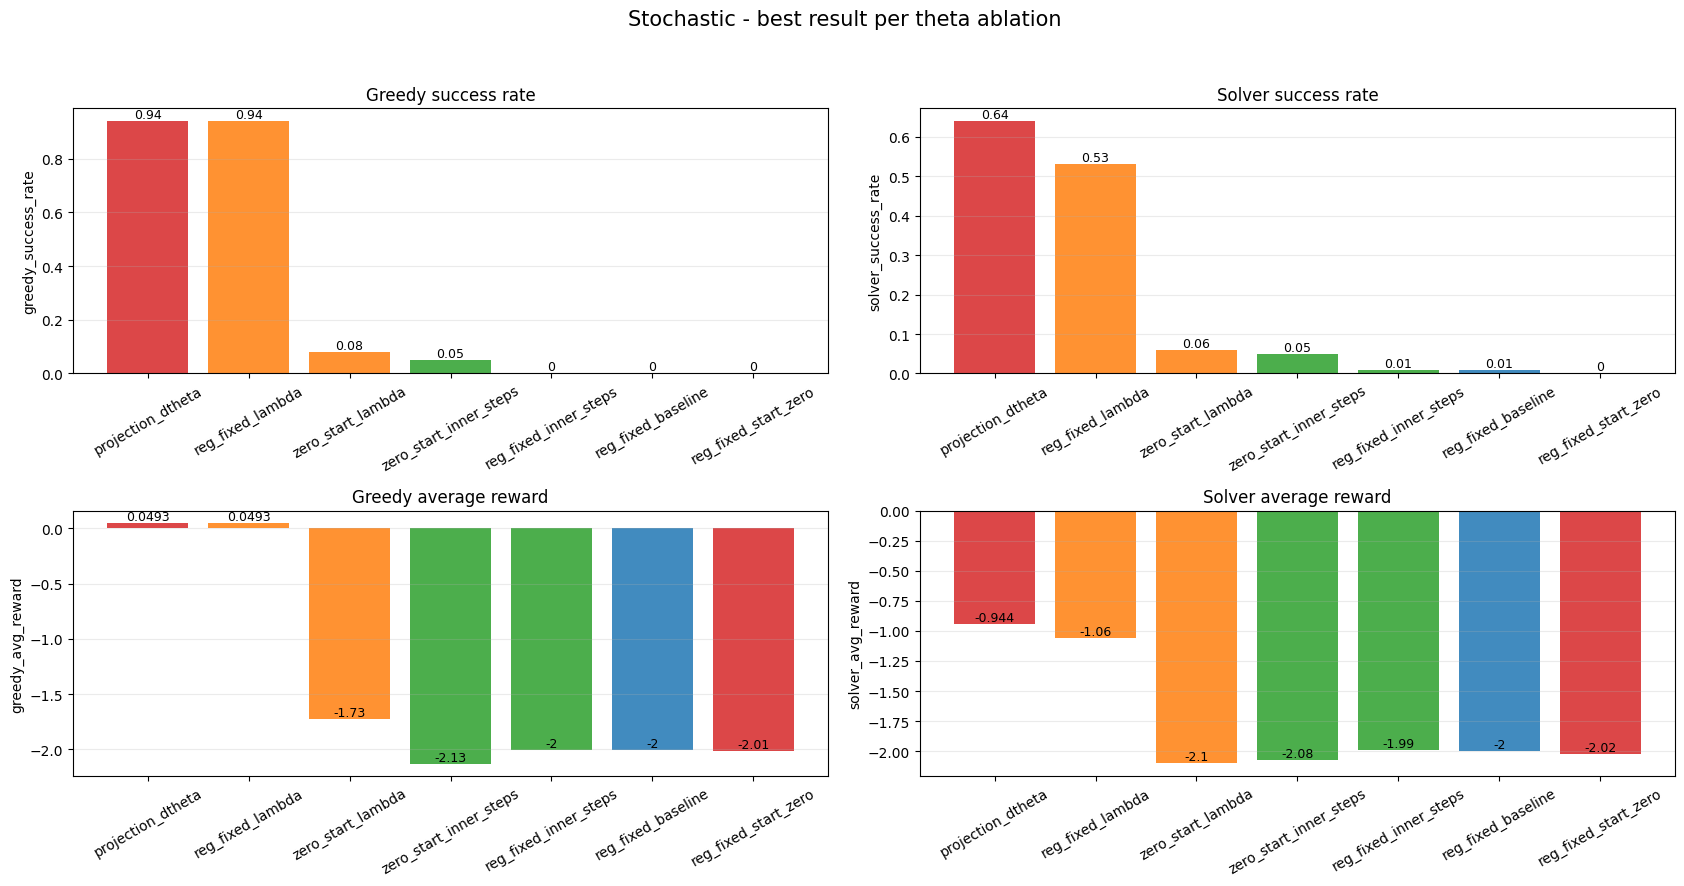

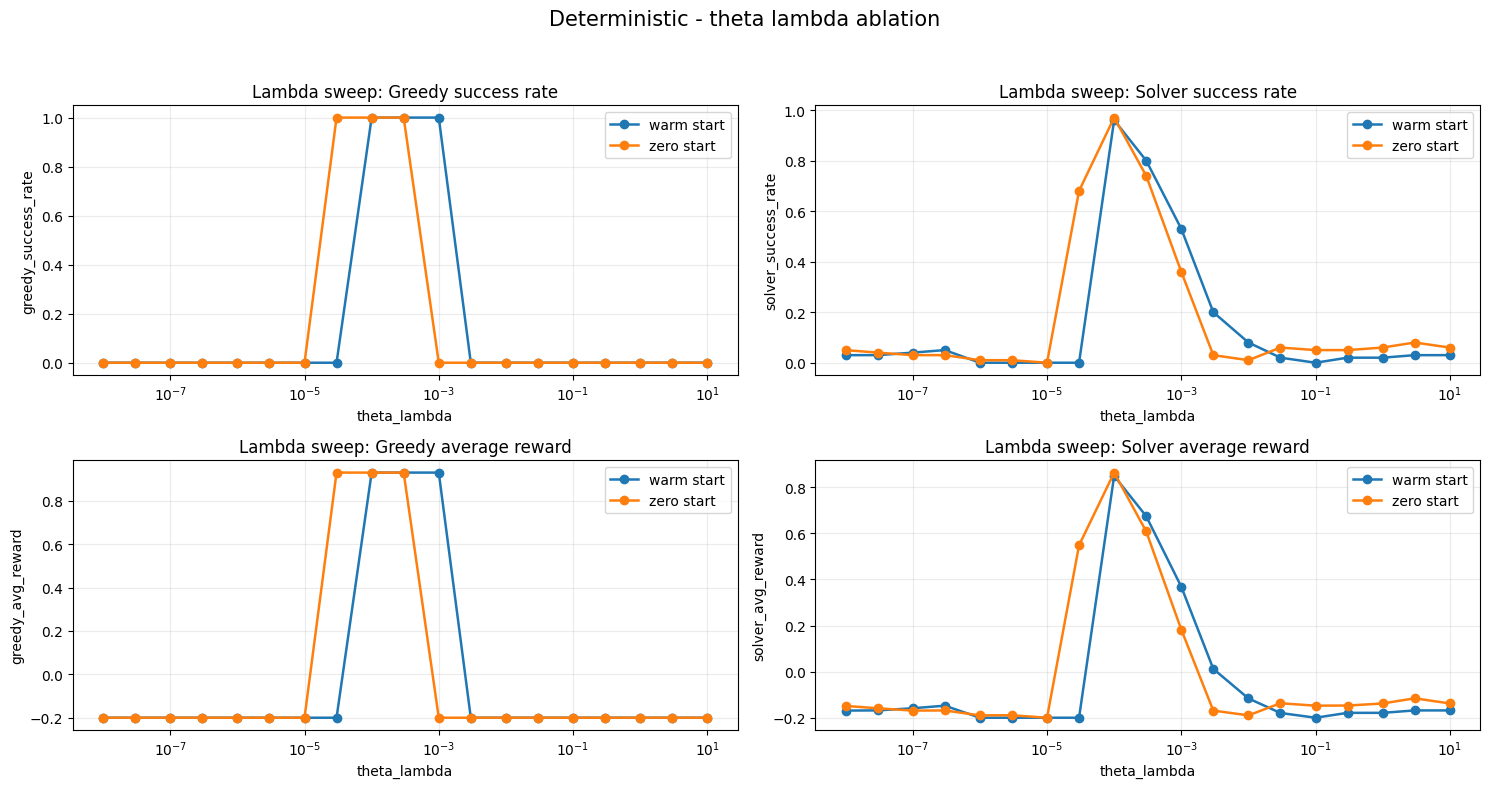

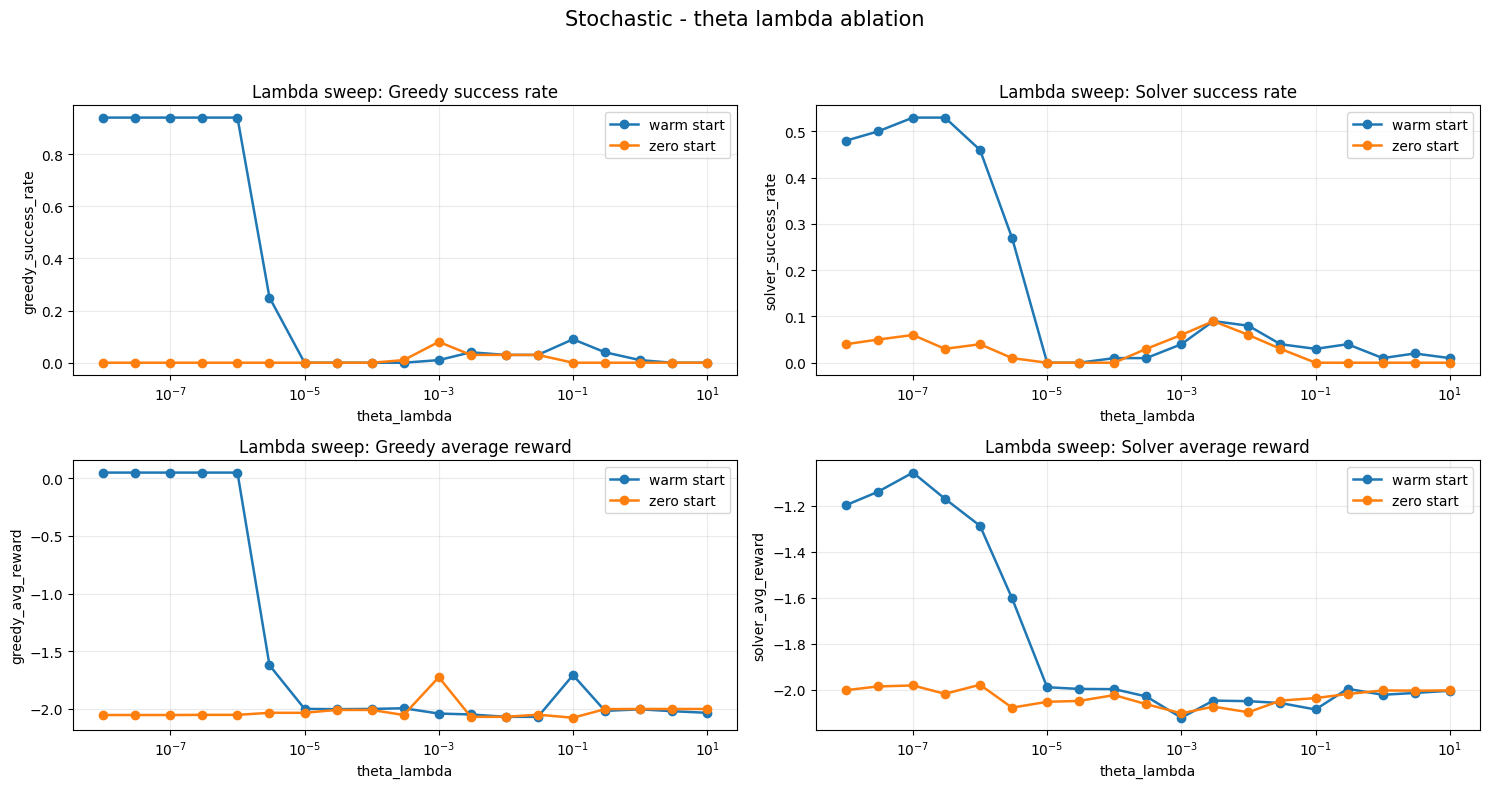

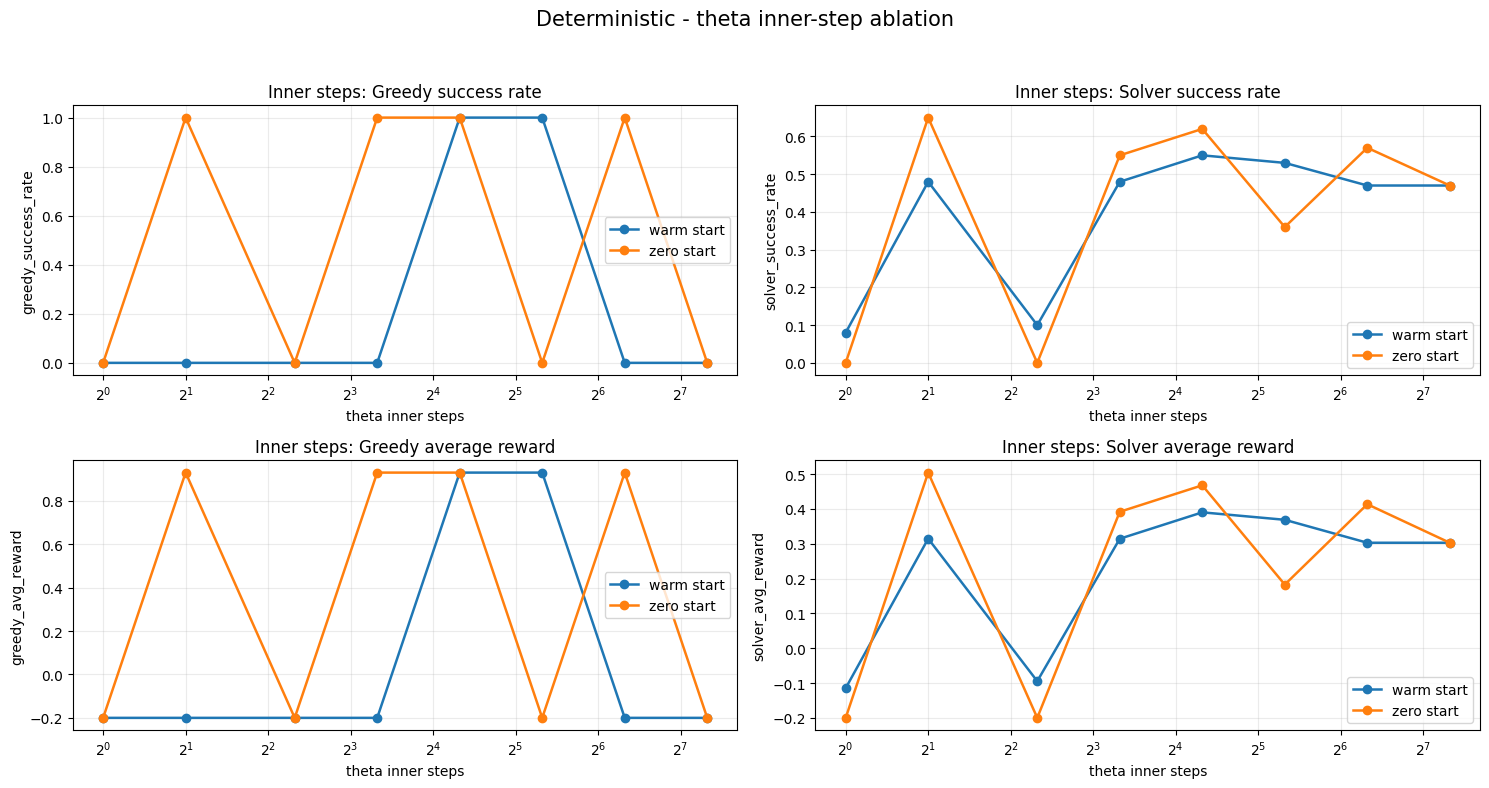

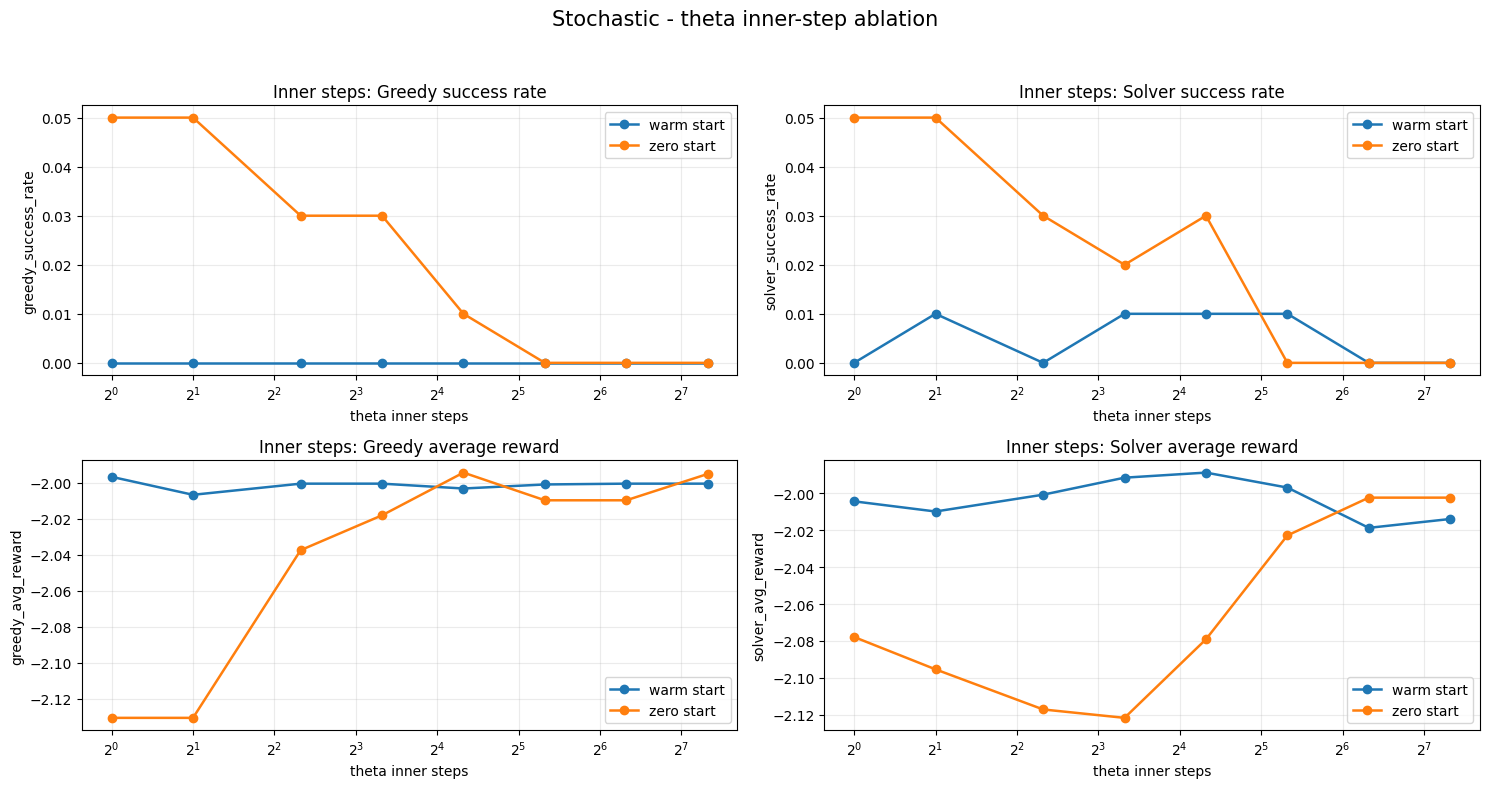

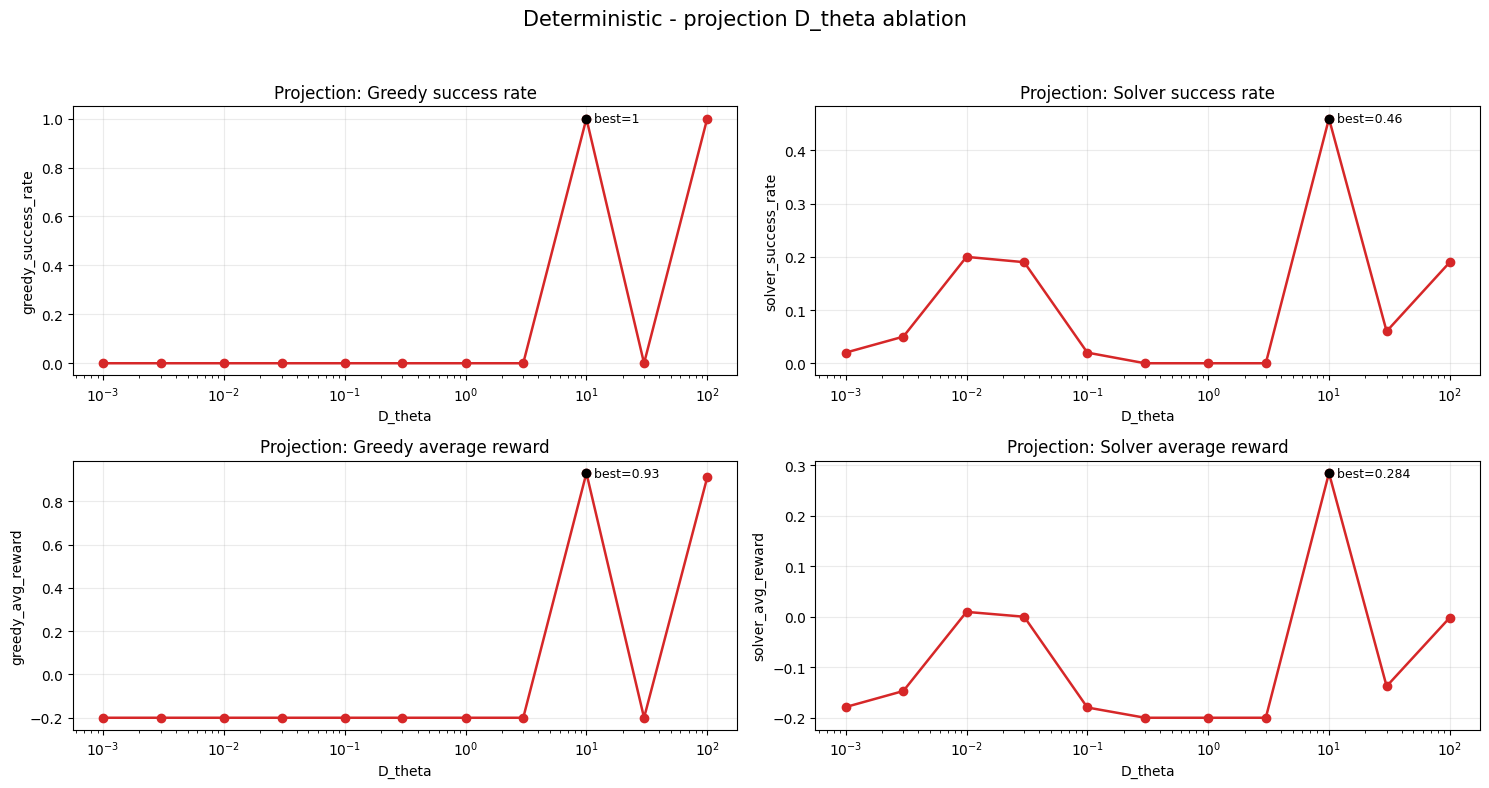

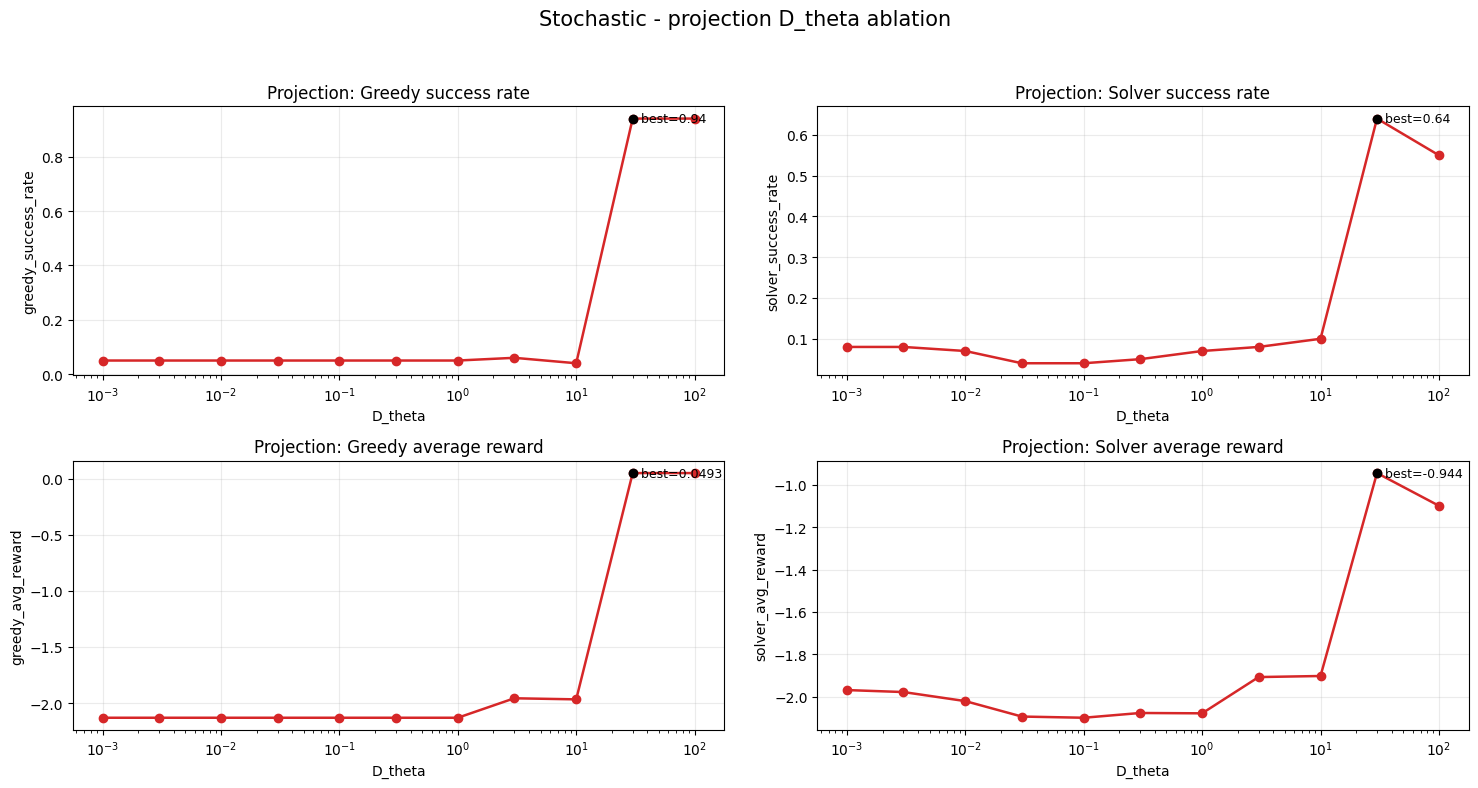


Best rows used for the main theta-ablation plots:


,problem,ablation,theta_mode,theta_start_mode,theta_lambda,D_theta,theta_inner_steps,greedy_success_rate,solver_success_rate,greedy_avg_reward,solver_avg_reward
0,deterministic,zero_start_lambda,reg_fixed,zero,1.000000e-04,NaN,40,1.00,0.97,0.93000,0.86390
1,deterministic,reg_fixed_lambda,reg_fixed,warm,1.000000e-04,NaN,40,1.00,0.96,0.93000,0.84960
2,deterministic,zero_start_inner_steps,reg_fixed,zero,1.000000e-03,NaN,2,1.00,0.65,0.93000,0.50410
3,deterministic,reg_fixed_inner_steps,reg_fixed,warm,1.000000e-03,NaN,20,1.00,0.55,0.93000,0.39000
4,deterministic,reg_fixed_baseline,reg_fixed,warm,1.000000e-03,NaN,40,1.00,0.53,0.93000,0.36860
5,deterministic,projection_dtheta,projection,warm,NaN,10.0,40,1.00,0.46,0.93000,0.28420
6,deterministic,reg_fixed_start_zero,reg_fixed,zero,1.000000e-03,NaN,40,0.00,0.36,-0.20000,0.18260
7,stochastic,projection_dtheta,projection,warm,NaN,30.0,40,0.94,0.64,0.04930,-0.94375
8,stochastic,reg_fixed_lambda,reg_fixed,warm,1.000000e-07,NaN,40,0.94,0.53,0.04930,-1.05575
9,stochastic,zero_start_lambda,reg_fixed,zero,1.000000e-03,NaN,40,0.08,0.06,-1.72530,-2.10210


In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / "setup.py").exists() and (p / "data").exists():
            return p
    return Path.cwd()


ROOT = find_repo_root()
RESULTS_DIR = ROOT / "data" / "results_clean" / "generalization"
THETA_CSV = RESULTS_DIR / "final_linear_5grid_tabular_theta_ablation.csv"

METRICS = [
    "greedy_success_rate",
    "solver_success_rate",
    "greedy_avg_reward",
    "solver_avg_reward",
]

PROBLEM_ORDER = ["deterministic", "stochastic"]

ABLATION_ORDER = [
    "reg_fixed_baseline",
    "reg_fixed_start_zero",
    "reg_fixed_lambda",
    "zero_start_lambda",
    "reg_fixed_inner_steps",
    "zero_start_inner_steps",
    "projection_dtheta",
]

RANK_COLUMNS = [
    "greedy_success_rate",
    "solver_success_rate",
    "greedy_avg_reward",
    "solver_avg_reward",
    "elapsed_seconds",
]

RANK_ASCENDING = [False, False, False, False, True]

METRIC_TITLES = {
    "greedy_success_rate": "Greedy success rate",
    "solver_success_rate": "Solver success rate",
    "greedy_avg_reward": "Greedy average reward",
    "solver_avg_reward": "Solver average reward",
}


print("Root:", ROOT)
print("Theta ablation:", THETA_CSV, "FOUND" if THETA_CSV.exists() else "MISSING")

if not THETA_CSV.exists():
    raise FileNotFoundError(
        f"Missing theta ablation CSV: {THETA_CSV}\n"
        "Run:\n"
        "python experiments/fogas_generalization_clean/scripts/"
        "grid_search_final_linear_5grid_tabular_theta_ablation.py --resume"
    )

df = pd.read_csv(THETA_CSV)

if "status" in df.columns:
    df = df[df["status"].eq("ok")].copy()

if df.empty:
    raise ValueError("Theta ablation CSV has no successful rows.")

rename = {
    "solver_avg_return": "solver_avg_reward",
    "greedy_avg_return": "greedy_avg_reward",
}
df = df.rename(columns={k: v for k, v in rename.items() if k in df.columns})

required = [
    "problem",
    "ablation",
    "theta_mode",
    "theta_lambda",
    "D_theta",
    "theta_inner_steps",
    "theta_start_mode",
    *METRICS,
]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["run_order"] = df["run_idx"] if "run_idx" in df.columns else np.arange(len(df))

df["problem"] = pd.Categorical(df["problem"], categories=PROBLEM_ORDER, ordered=True)
df["ablation"] = pd.Categorical(df["ablation"], categories=ABLATION_ORDER, ordered=True)

df["theta_config"] = (
    df["ablation"].astype(str)
    + " | mode=" + df["theta_mode"].astype(str)
    + " start=" + df["theta_start_mode"].astype(str)
    + " lambda=" + df["theta_lambda"].astype(str)
    + " D=" + df["D_theta"].astype(str)
    + " inner=" + df["theta_inner_steps"].astype(str)
)

rank_cols = [c for c in RANK_COLUMNS if c in df.columns]
rank_ascending = RANK_ASCENDING[: len(rank_cols)]


def best_rows_per_group(data, group_cols):
    return (
        data.sort_values(
            group_cols + rank_cols,
            ascending=[True] * len(group_cols) + rank_ascending,
        )
        .groupby(group_cols, as_index=False, observed=True)
        .head(1)
        .reset_index(drop=True)
    )


# ============================================================
# 1. Statistics:
#    Best result for every theta ablation type.
#    Deterministic first, then stochastic.
# ============================================================

best_by_ablation = best_rows_per_group(df, ["problem", "ablation"])

best_by_ablation = best_by_ablation.sort_values(
    ["problem", *rank_cols],
    ascending=[True] + rank_ascending,
).reset_index(drop=True)

stats_columns = [
    "problem",
    "ablation",
    "theta_mode",
    "theta_start_mode",
    "theta_lambda",
    "D_theta",
    "theta_inner_steps",
    "theta_lr",
    *METRICS,
]

if "elapsed_seconds" in best_by_ablation.columns:
    stats_columns.append("elapsed_seconds")

print("\nBest result for every theta ablation type:")
display(best_by_ablation[stats_columns])

for problem in PROBLEM_ORDER:
    sub = best_by_ablation[best_by_ablation["problem"].astype(str).eq(problem)].copy()
    if sub.empty:
        continue

    print(f"\nBest theta-ablation results: {problem}")
    display(sub[stats_columns])


# ============================================================
# 2. Main bar plots:
#    For each problem, show all 4 metrics.
#    Each bar is the best result for that theta ablation type.
# ============================================================

for problem in PROBLEM_ORDER:
    sub = best_by_ablation[best_by_ablation["problem"].astype(str).eq(problem)].copy()

    if sub.empty:
        print(f"No rows for problem={problem}")
        continue

    sub = sub.sort_values(rank_cols, ascending=rank_ascending)
    labels = sub["ablation"].astype(str).tolist()

    fig, axes = plt.subplots(2, 2, figsize=(17, 9))
    axes = axes.ravel()

    for ax, metric in zip(axes, METRICS):
        values = sub[metric].astype(float).values

        colors = [
            "tab:blue" if "baseline" in label
            else "tab:orange" if "lambda" in label
            else "tab:green" if "inner_steps" in label
            else "tab:red"
            for label in labels
        ]

        ax.bar(labels, values, color=colors, alpha=0.85)
        ax.set_title(METRIC_TITLES.get(metric, metric))
        ax.set_ylabel(metric)
        ax.grid(True, axis="y", alpha=0.25)
        ax.tick_params(axis="x", rotation=30)

        for idx, value in enumerate(values):
            ax.text(idx, value, f"{value:.3g}", ha="center", va="bottom", fontsize=9)

    fig.suptitle(
        f"{problem.capitalize()} - best result per theta ablation",
        fontsize=15,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# ============================================================
# 3. Lambda sweep plots:
#    Warm start vs zero start.
# ============================================================

for problem in PROBLEM_ORDER:
    sub = df[
        df["problem"].astype(str).eq(problem)
        & df["ablation"].astype(str).isin(["reg_fixed_lambda", "zero_start_lambda"])
    ].copy()

    if sub.empty:
        print(f"No theta-lambda rows for problem={problem}")
        continue

    sub = sub.dropna(subset=["theta_lambda"]).sort_values("theta_lambda")

    fig, axes = plt.subplots(2, 2, figsize=(15, 8))
    axes = axes.ravel()

    for ax, metric in zip(axes, METRICS):
        for ablation, g in sub.groupby("ablation", observed=True):
            label = "warm start" if str(ablation) == "reg_fixed_lambda" else "zero start"
            ax.plot(
                g["theta_lambda"],
                g[metric],
                marker="o",
                linewidth=1.8,
                label=label,
            )

        ax.set_xscale("log")
        ax.set_title(f"Lambda sweep: {METRIC_TITLES.get(metric, metric)}")
        ax.set_xlabel("theta_lambda")
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.25)
        ax.legend()

    fig.suptitle(f"{problem.capitalize()} - theta lambda ablation", fontsize=15)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# ============================================================
# 4. Inner-step sweep plots:
#    Warm start vs zero start.
# ============================================================

for problem in PROBLEM_ORDER:
    sub = df[
        df["problem"].astype(str).eq(problem)
        & df["ablation"].astype(str).isin(["reg_fixed_inner_steps", "zero_start_inner_steps"])
    ].copy()

    if sub.empty:
        print(f"No theta-inner-step rows for problem={problem}")
        continue

    sub = sub.sort_values("theta_inner_steps")

    fig, axes = plt.subplots(2, 2, figsize=(15, 8))
    axes = axes.ravel()

    for ax, metric in zip(axes, METRICS):
        for ablation, g in sub.groupby("ablation", observed=True):
            label = "warm start" if str(ablation) == "reg_fixed_inner_steps" else "zero start"
            ax.plot(
                g["theta_inner_steps"],
                g[metric],
                marker="o",
                linewidth=1.8,
                label=label,
            )

        ax.set_xscale("log", base=2)
        ax.set_title(f"Inner steps: {METRIC_TITLES.get(metric, metric)}")
        ax.set_xlabel("theta inner steps")
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.25)
        ax.legend()

    fig.suptitle(f"{problem.capitalize()} - theta inner-step ablation", fontsize=15)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# ============================================================
# 5. Projection D_theta sweep plots.
# ============================================================

for problem in PROBLEM_ORDER:
    sub = df[
        df["problem"].astype(str).eq(problem)
        & df["ablation"].astype(str).eq("projection_dtheta")
    ].copy()

    if sub.empty:
        print(f"No projection D_theta rows for problem={problem}")
        continue

    sub = sub.dropna(subset=["D_theta"]).sort_values("D_theta")

    fig, axes = plt.subplots(2, 2, figsize=(15, 8))
    axes = axes.ravel()

    for ax, metric in zip(axes, METRICS):
        ax.plot(
            sub["D_theta"],
            sub[metric],
            marker="o",
            linewidth=1.8,
            color="tab:red",
        )

        best_idx = sub[metric].astype(float).idxmax()
        best_row = sub.loc[best_idx]
        ax.scatter(best_row["D_theta"], best_row[metric], color="black", zorder=5)
        ax.text(
            best_row["D_theta"],
            best_row[metric],
            f"  best={best_row[metric]:.3g}",
            va="center",
            fontsize=9,
        )

        ax.set_xscale("log")
        ax.set_title(f"Projection: {METRIC_TITLES.get(metric, metric)}")
        ax.set_xlabel("D_theta")
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.25)

    fig.suptitle(f"{problem.capitalize()} - projection D_theta ablation", fontsize=15)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# ============================================================
# 6. Compact table used for the main plots.
# ============================================================

plot_table_columns = [
    "problem",
    "ablation",
    "theta_mode",
    "theta_start_mode",
    "theta_lambda",
    "D_theta",
    "theta_inner_steps",
    *METRICS,
]

print("\nBest rows used for the main theta-ablation plots:")
display(
    best_by_ablation
    .sort_values(["problem", *rank_cols], ascending=[True] + rank_ascending)
    [plot_table_columns]
)